In [ ]:
import sys
sys.path.append('/Users/paolamartire/shocks')
abspath = '/Users/paolamartire/shocks'
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
import Utilities.prelude as prel
import healpy as hp
import Utilities.operators as op

18.6046511627907


In [ ]:
# Parameters
N = 4
coord_centre = np.array([9.0, 0.0, 0.0])  
vel_centre = np.array([-0.1, -2, 0.0])  
vel_radial_centre, _, _ = op.to_spherical_components(vel_centre[0], vel_centre[1], vel_centre[2], coord_centre[0], coord_centre[1], coord_centre[2])
centre = (coord_centre, vel_centre)
times = np.arange(0, 20.1, .1)
# grav_force_centre = -1 * np.array(coord_centre) / np.linalg.norm(coord_centre)**3 # G = 1
speed = np.abs(np.sqrt(2 / np.linalg.norm(coord_centre)) + np.abs(vel_radial_centre))
print('speed ratio centre/particle:', vel_radial_centre/speed, 'speed:', speed, 'radial velocity:', vel_radial_centre)

def orbital_energy(r, vel):
    return 0.5 * vel**2 - 1/r

def r_lim_unb(v_r_tot):
    r_thres = 2 / v_r_tot**2
    return r_thres

orb_en_start = orbital_energy(np.linalg.norm(coord_centre), vel_radial_centre + speed)
print('orbital energy at launch:', orb_en_start)

speed ratio centre/particle: -0.17500736581776363 speed: 0.5714045207910317 radial velocity: -0.1
orbital energy at launch: 0.0


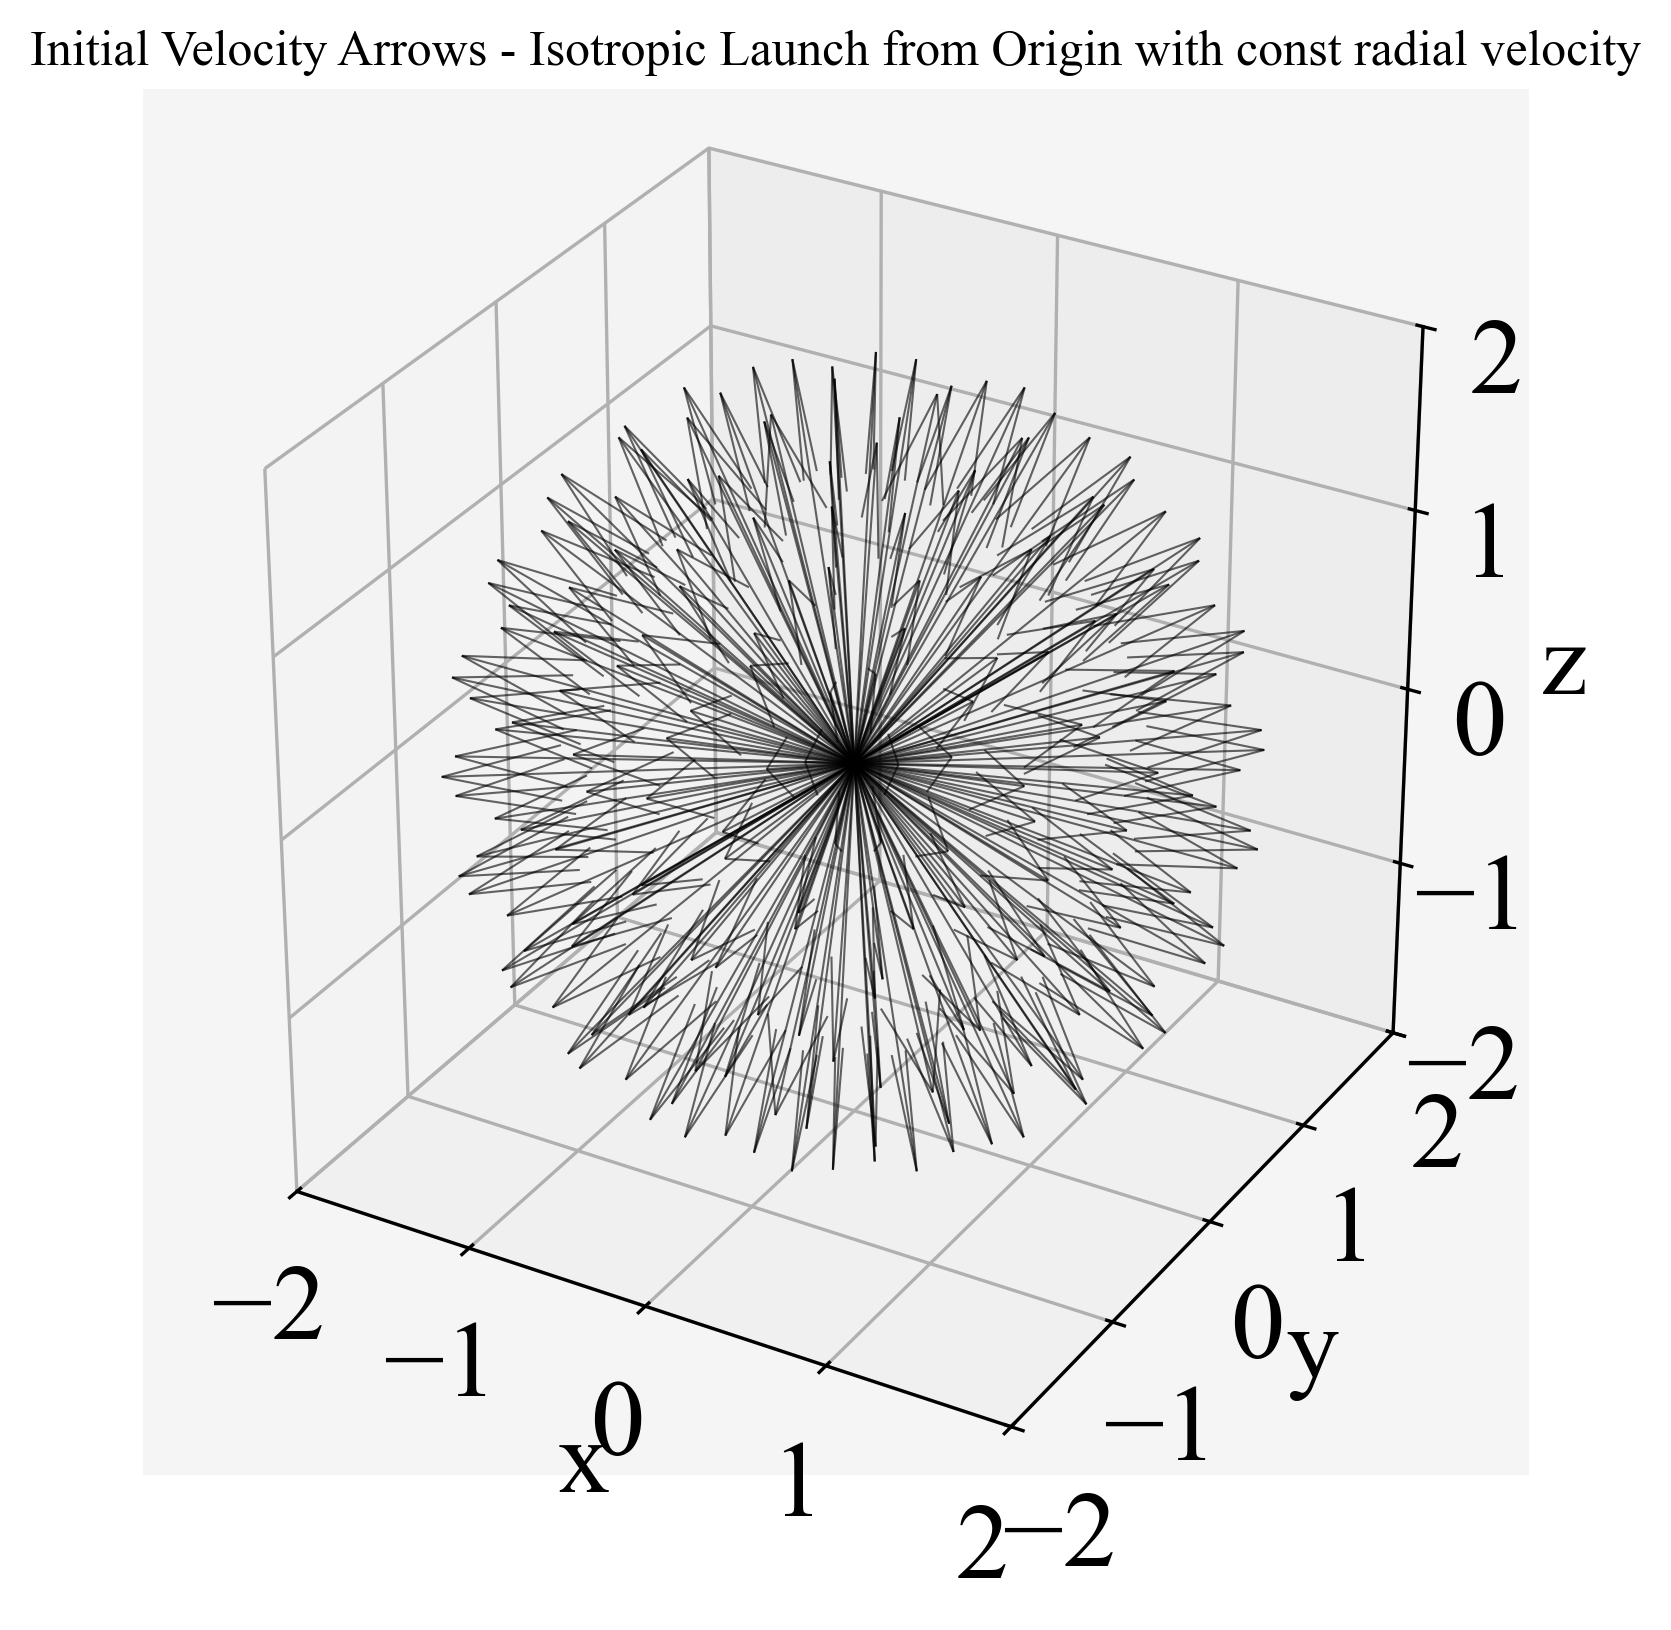

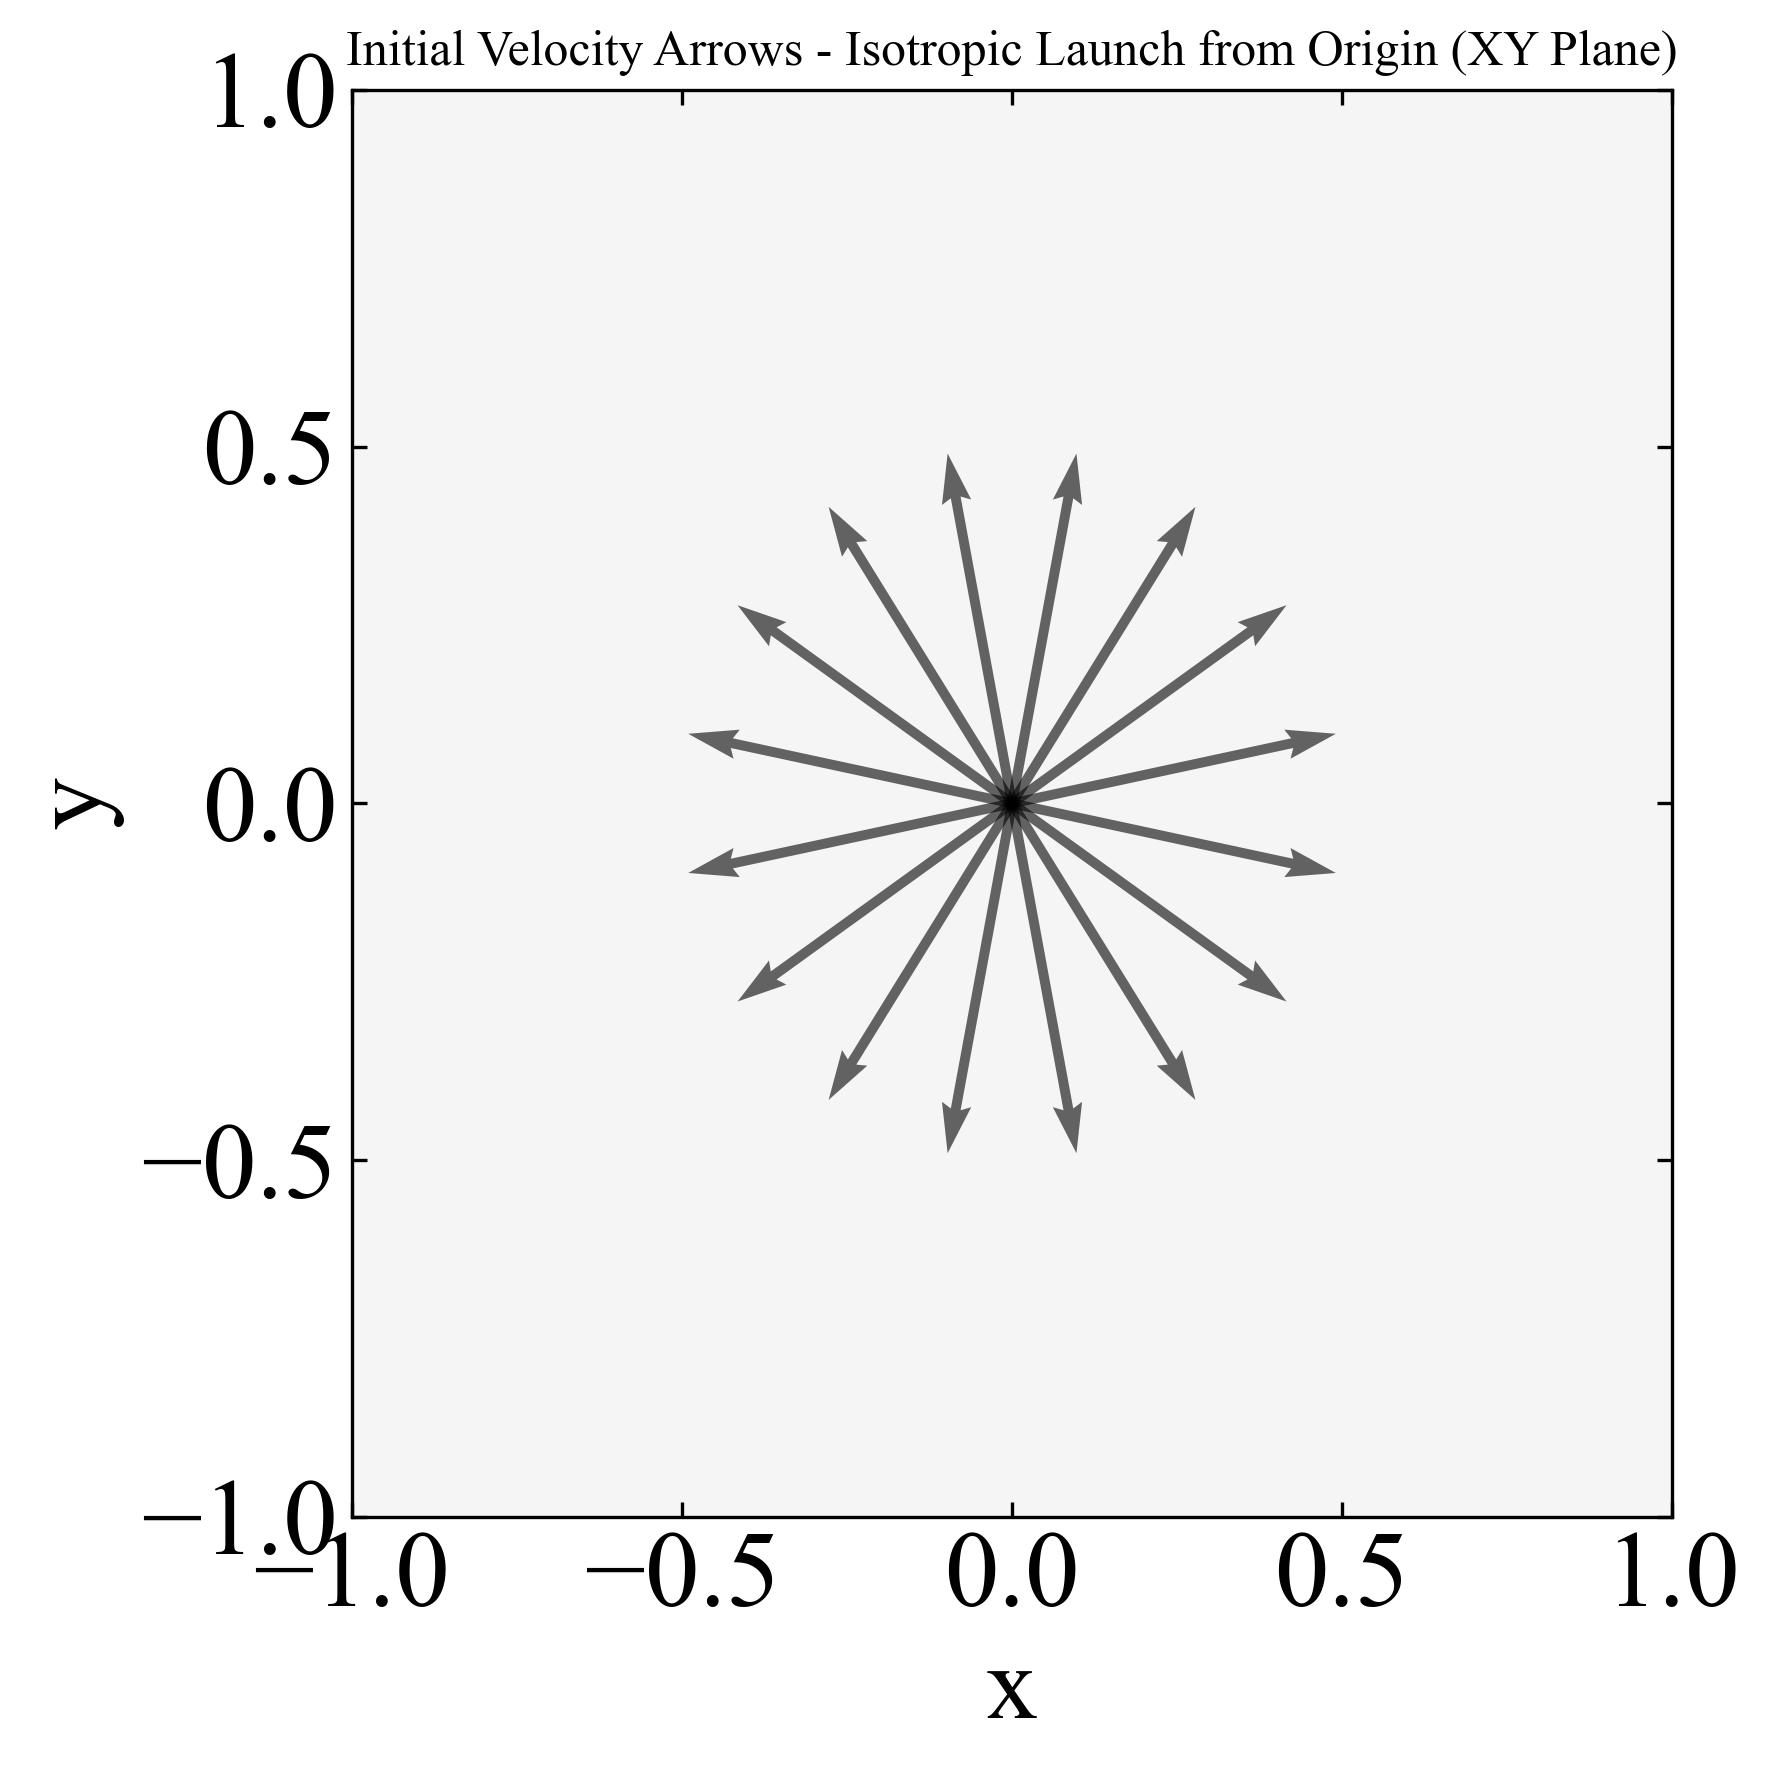

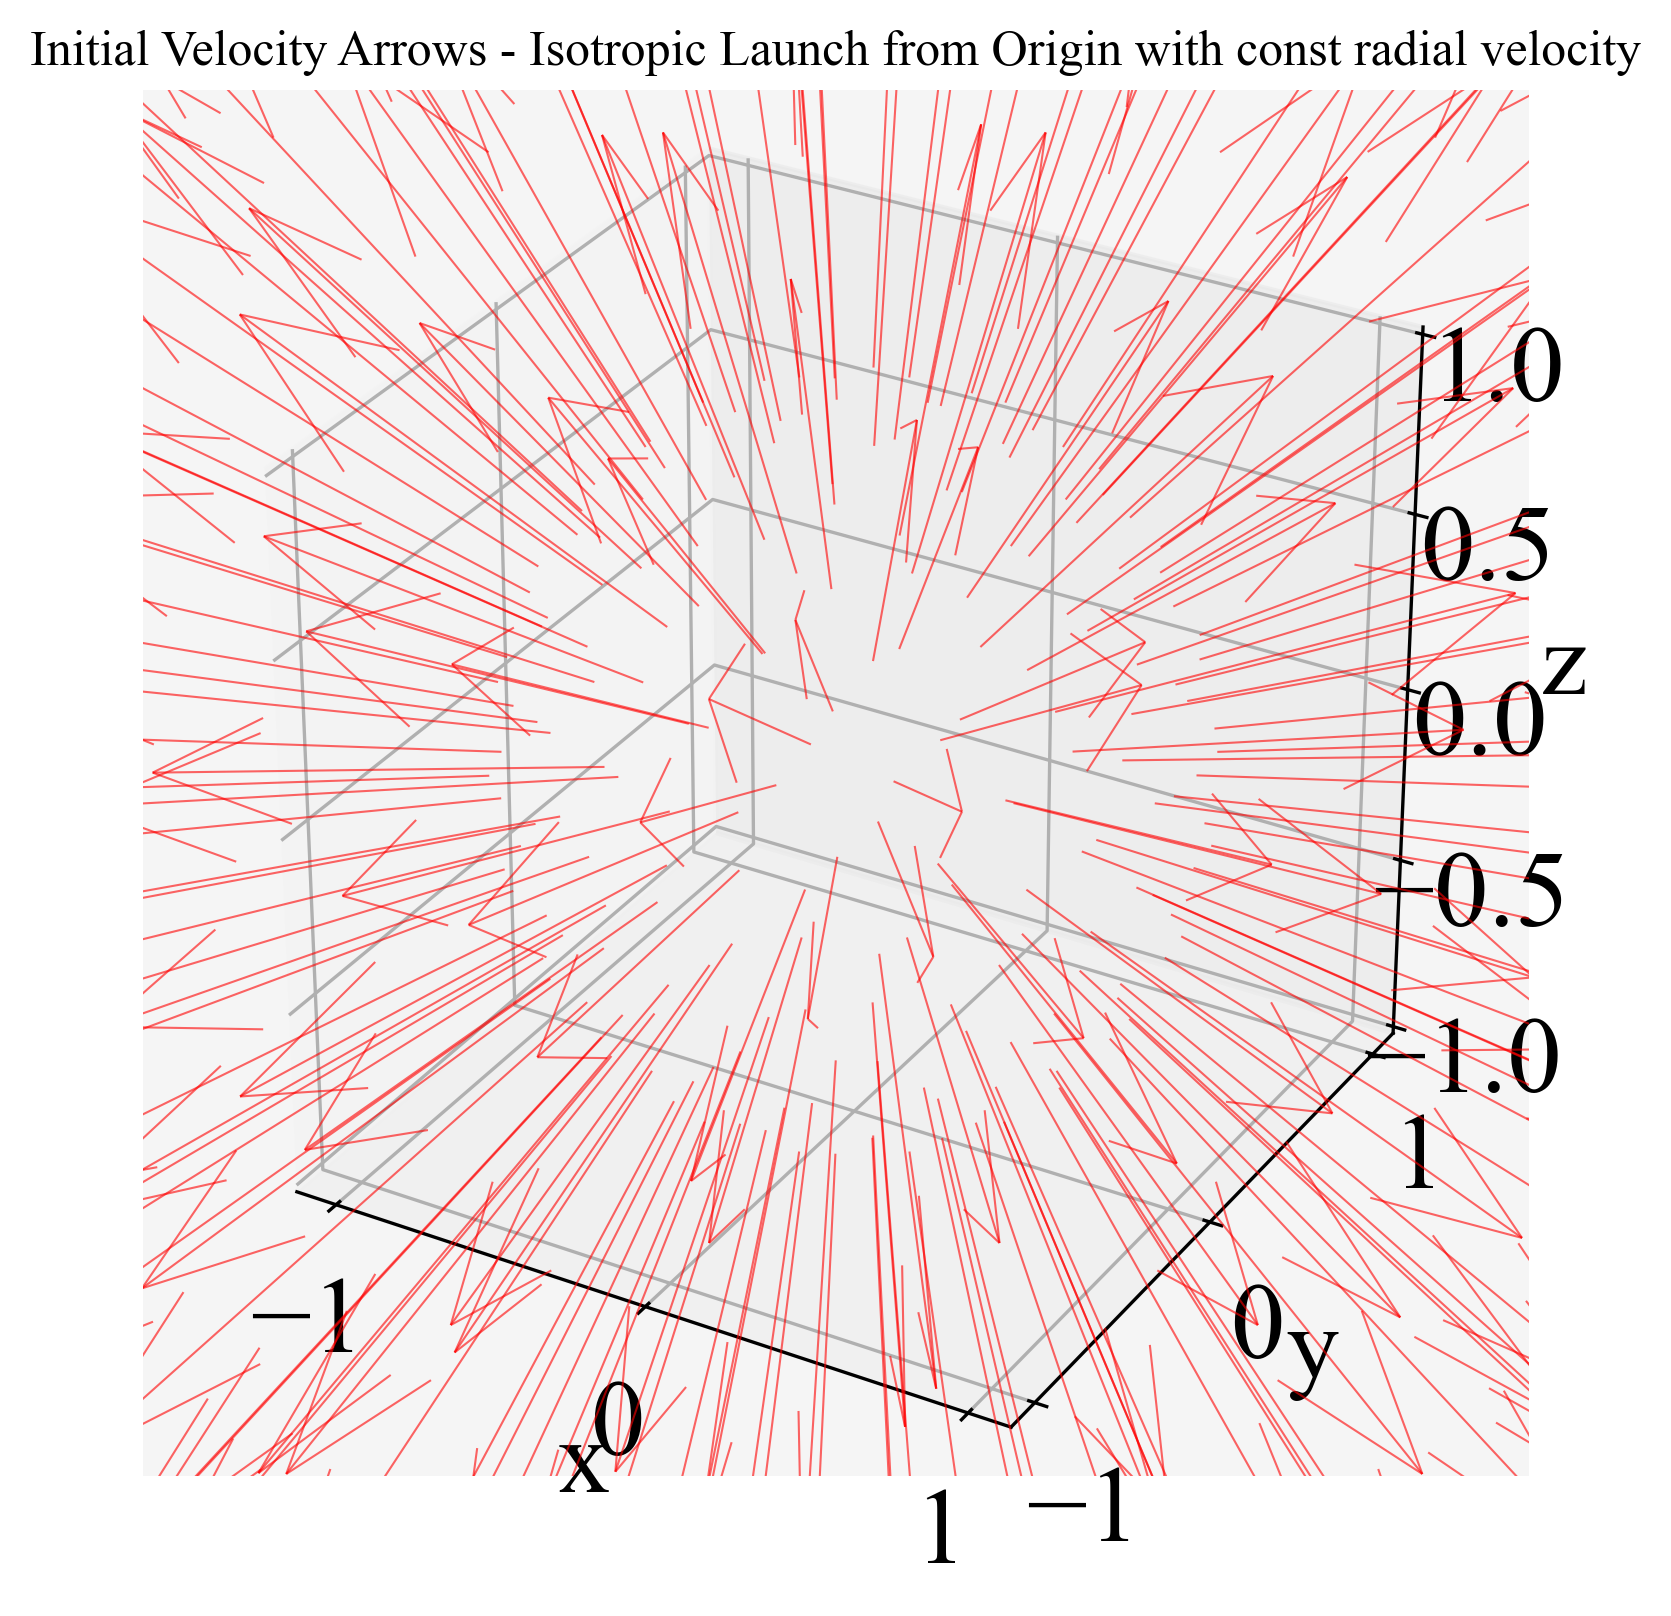

In [11]:
def launch_isotropic_particles_static(NSIDE, speed, dt):
    NPIX = hp.nside2npix(NSIDE)
    # create random isotropic directions for the launch and use them for your velocity
    observers_xyz = hp.pix2vec(NSIDE, range(NPIX))
    observers_xyz = np.array(observers_xyz)
    vx, vy, vz = observers_xyz[0], observers_xyz[1], observers_xyz[2]
    vx *= speed
    vy *= speed
    vz *= speed

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    scale = 2.0
    ax.quiver(0, 0, 0, vx, vy, vz, 
            length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'k')
    # Equal aspect ratio
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('Initial Velocity Arrows - Isotropic Launch from Origin with const radial velocity')
    max_range = scale * speed
    ax.set_xlim(-max_range, max_range)
    ax.set_ylim(-max_range, max_range)
    ax.set_zlim(-max_range, max_range)
    ax.set_box_aspect([1, 1, 1]) 

    fig = plt.figure(figsize=(6,6))
    plt.quiver(np.zeros_like(vx[vz==0]), np.zeros_like(vy[vz==0]), vx[vz==0], vy[vz==0],
            angles='xy', scale_units='xy', scale=2, alpha=0.6, linewidth=0.5, color = 'k')
    plt.xlim(-speed, speed)
    plt.ylim(-speed, speed)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Initial Velocity Arrows - Isotropic Launch from Origin (XY Plane)')
    plt.tight_layout()

    # Start at the origin and move ballistically for time dt
    x = vx * dt
    y = vy * dt
    z = vz * dt

    pos = np.column_stack((x, y, z))
    vel = np.column_stack((vx, vy, vz))
    return pos, vel


# Example
dt_single = 1
pos, vel = launch_isotropic_particles_static(N, speed=1.0, dt=dt_single)
xN, yN, zN = pos[:, 0], pos[:, 1], pos[:, 2]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
scale = 2.0
ax.quiver(xN, yN, zN, vel[:, 0], vel[:, 1], vel[:, 2], 
        length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'r')
# Equal aspect ratio
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Initial Velocity Arrows - Isotropic Launch from Origin with const radial velocity')
ax.set_box_aspect([1, 1, 1]) 



Single launch at t=0 with speed: 0.5714045207910317. Frame: centre, central point in [9. 0. 0.] with v = [-0.1 -2.   0. ]
After dt = 1, positive x: 96, negative x: 96
Positive x: 96, Negative x: 96 after dt = 1


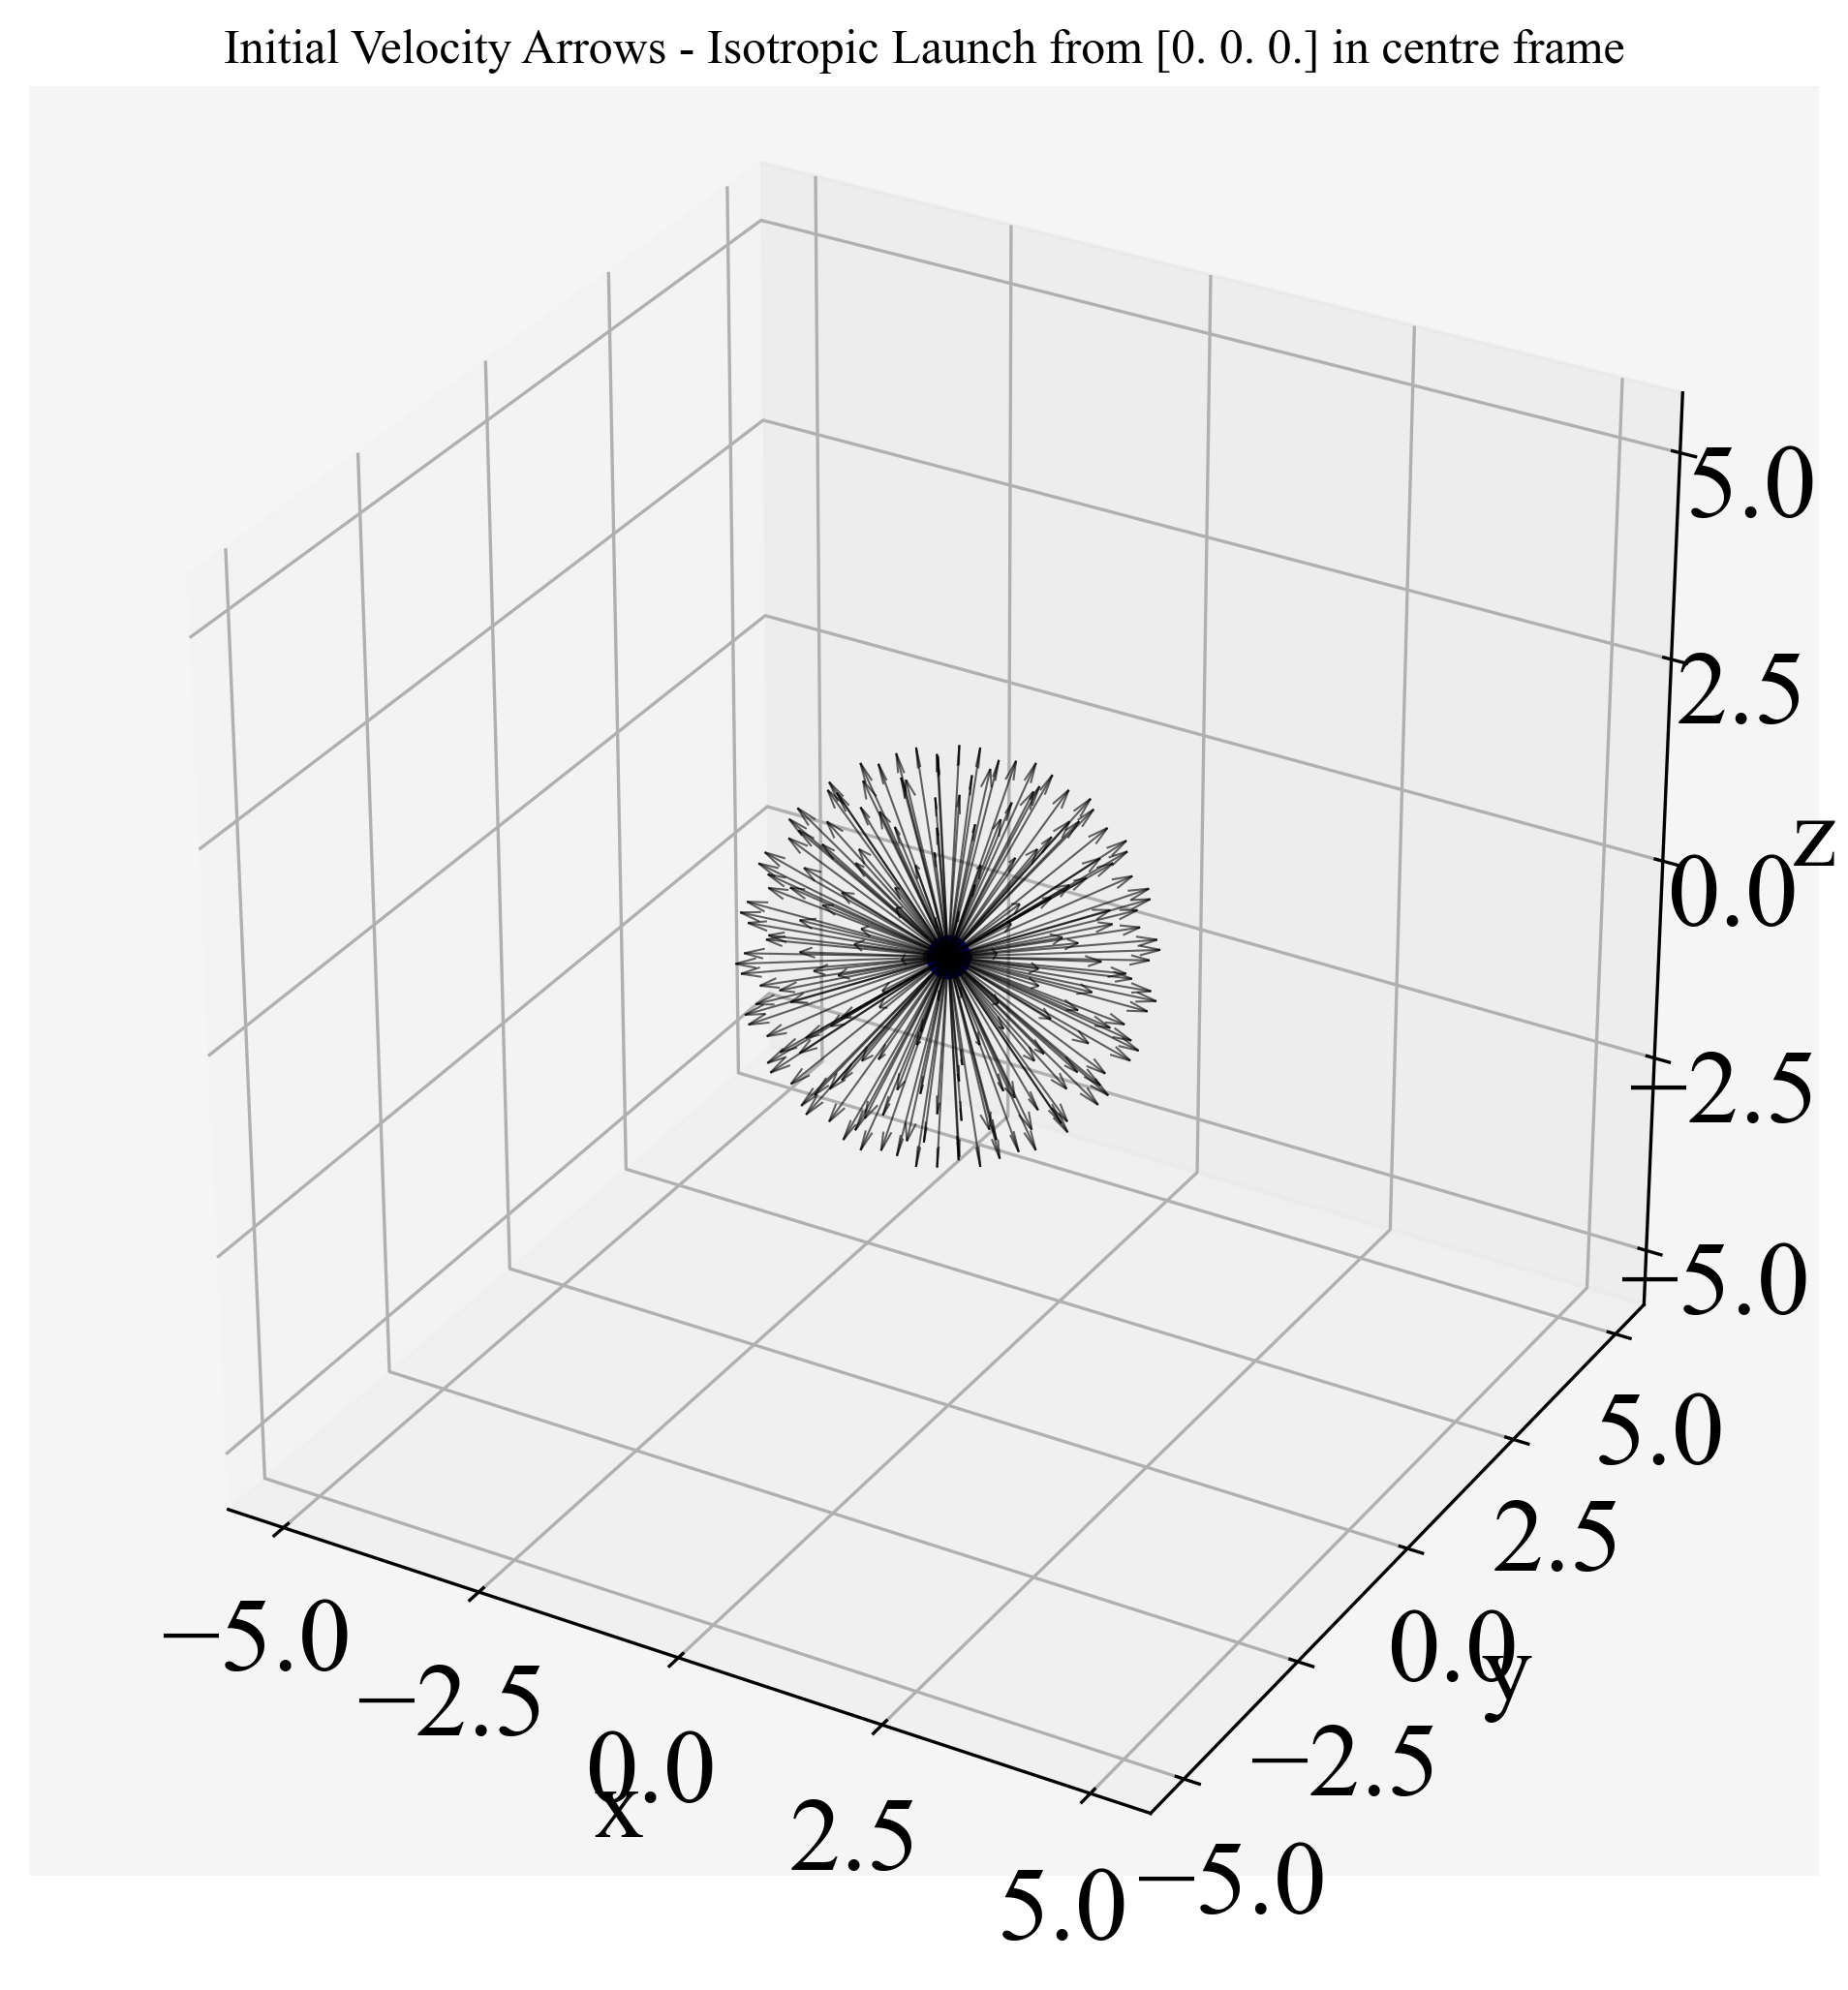

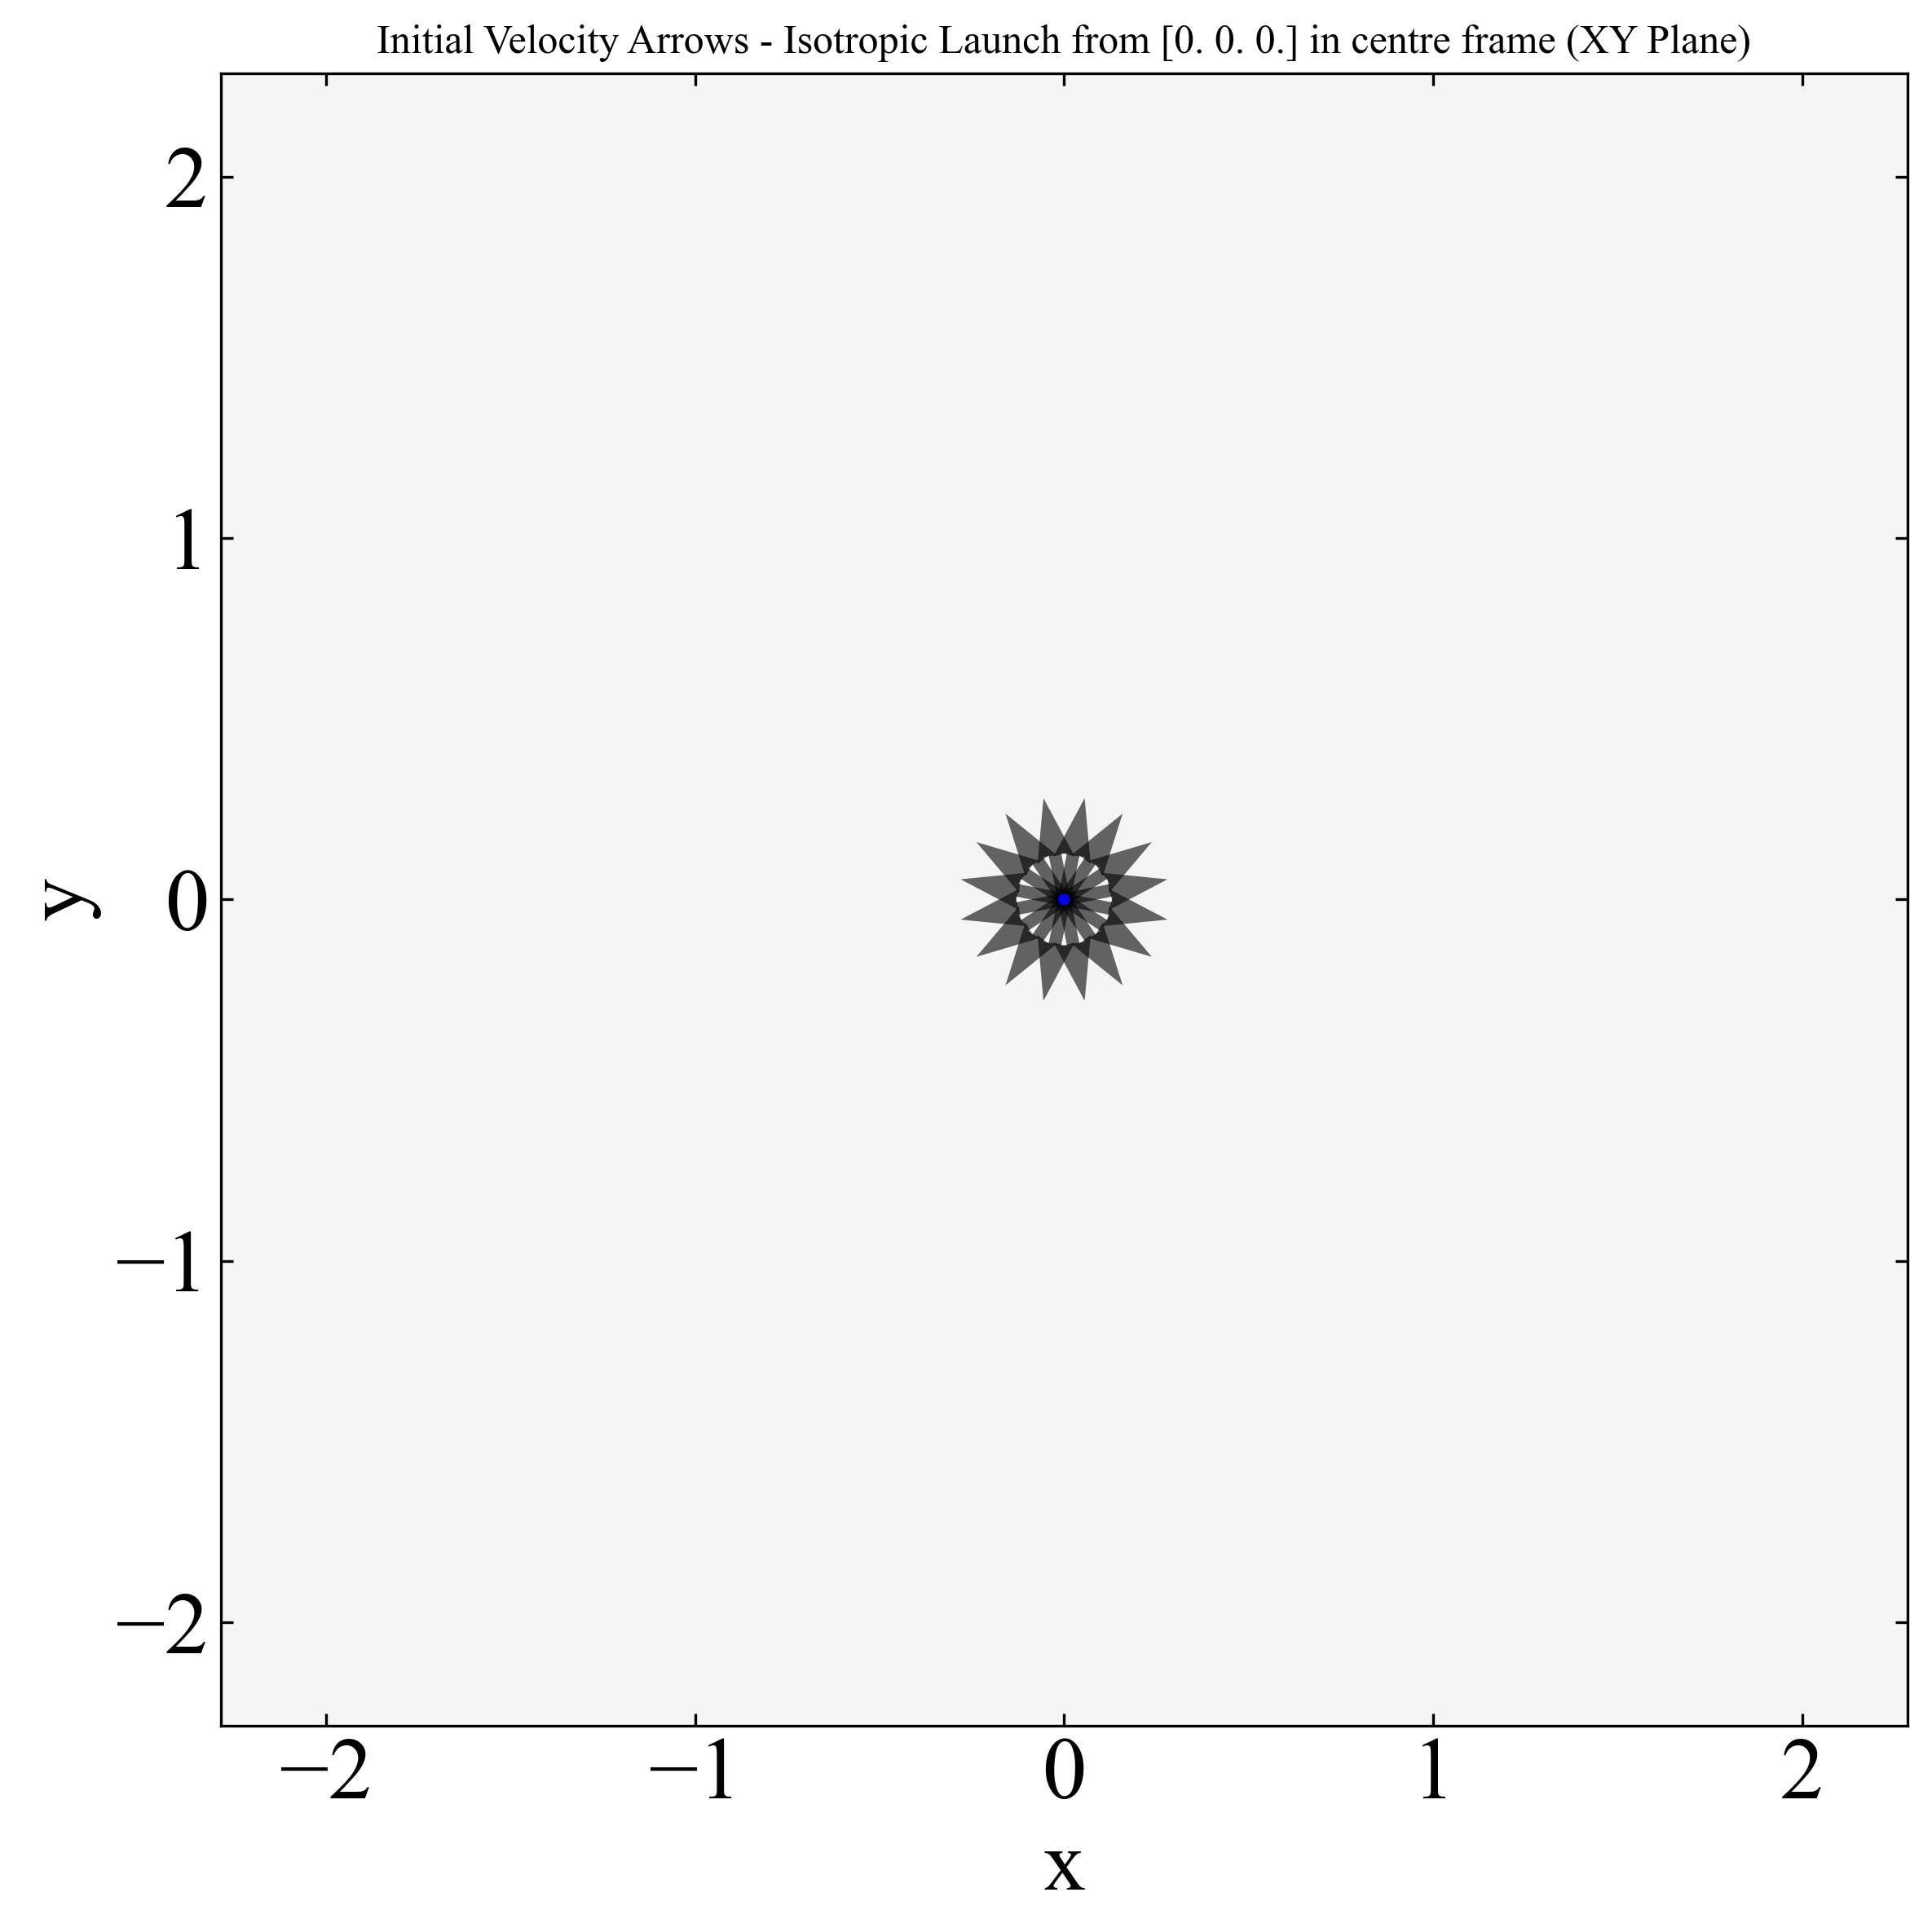

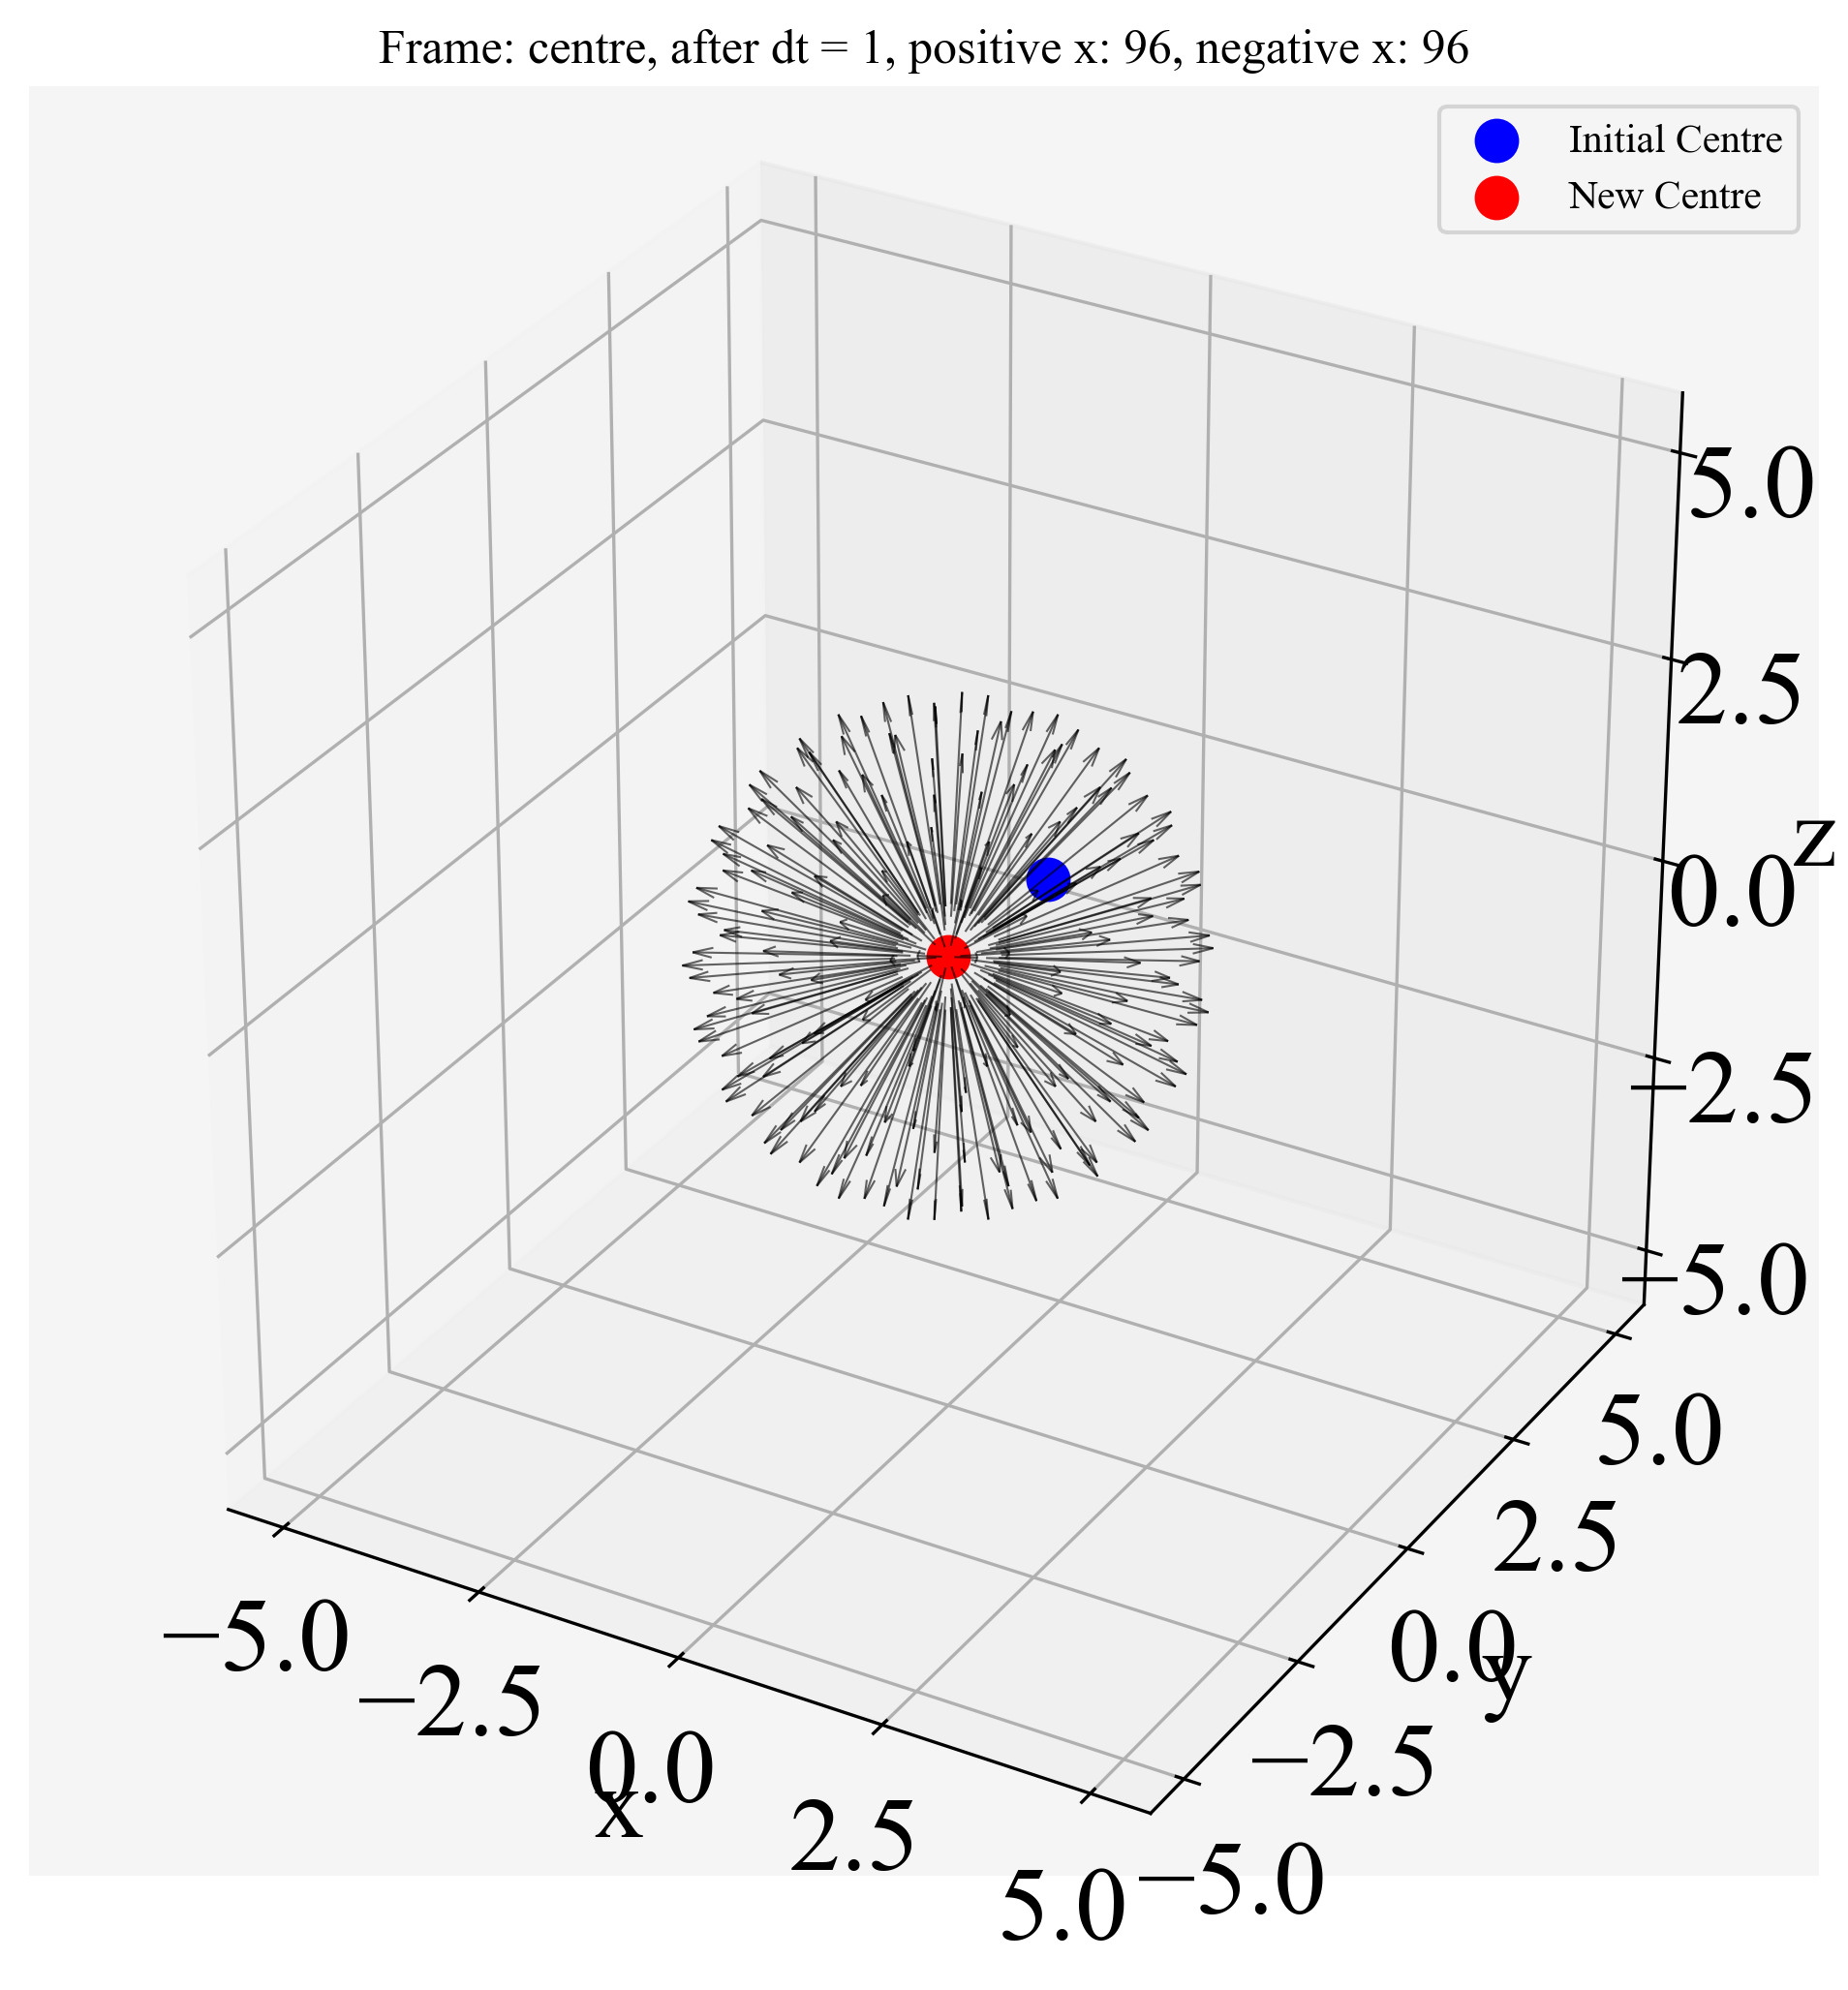

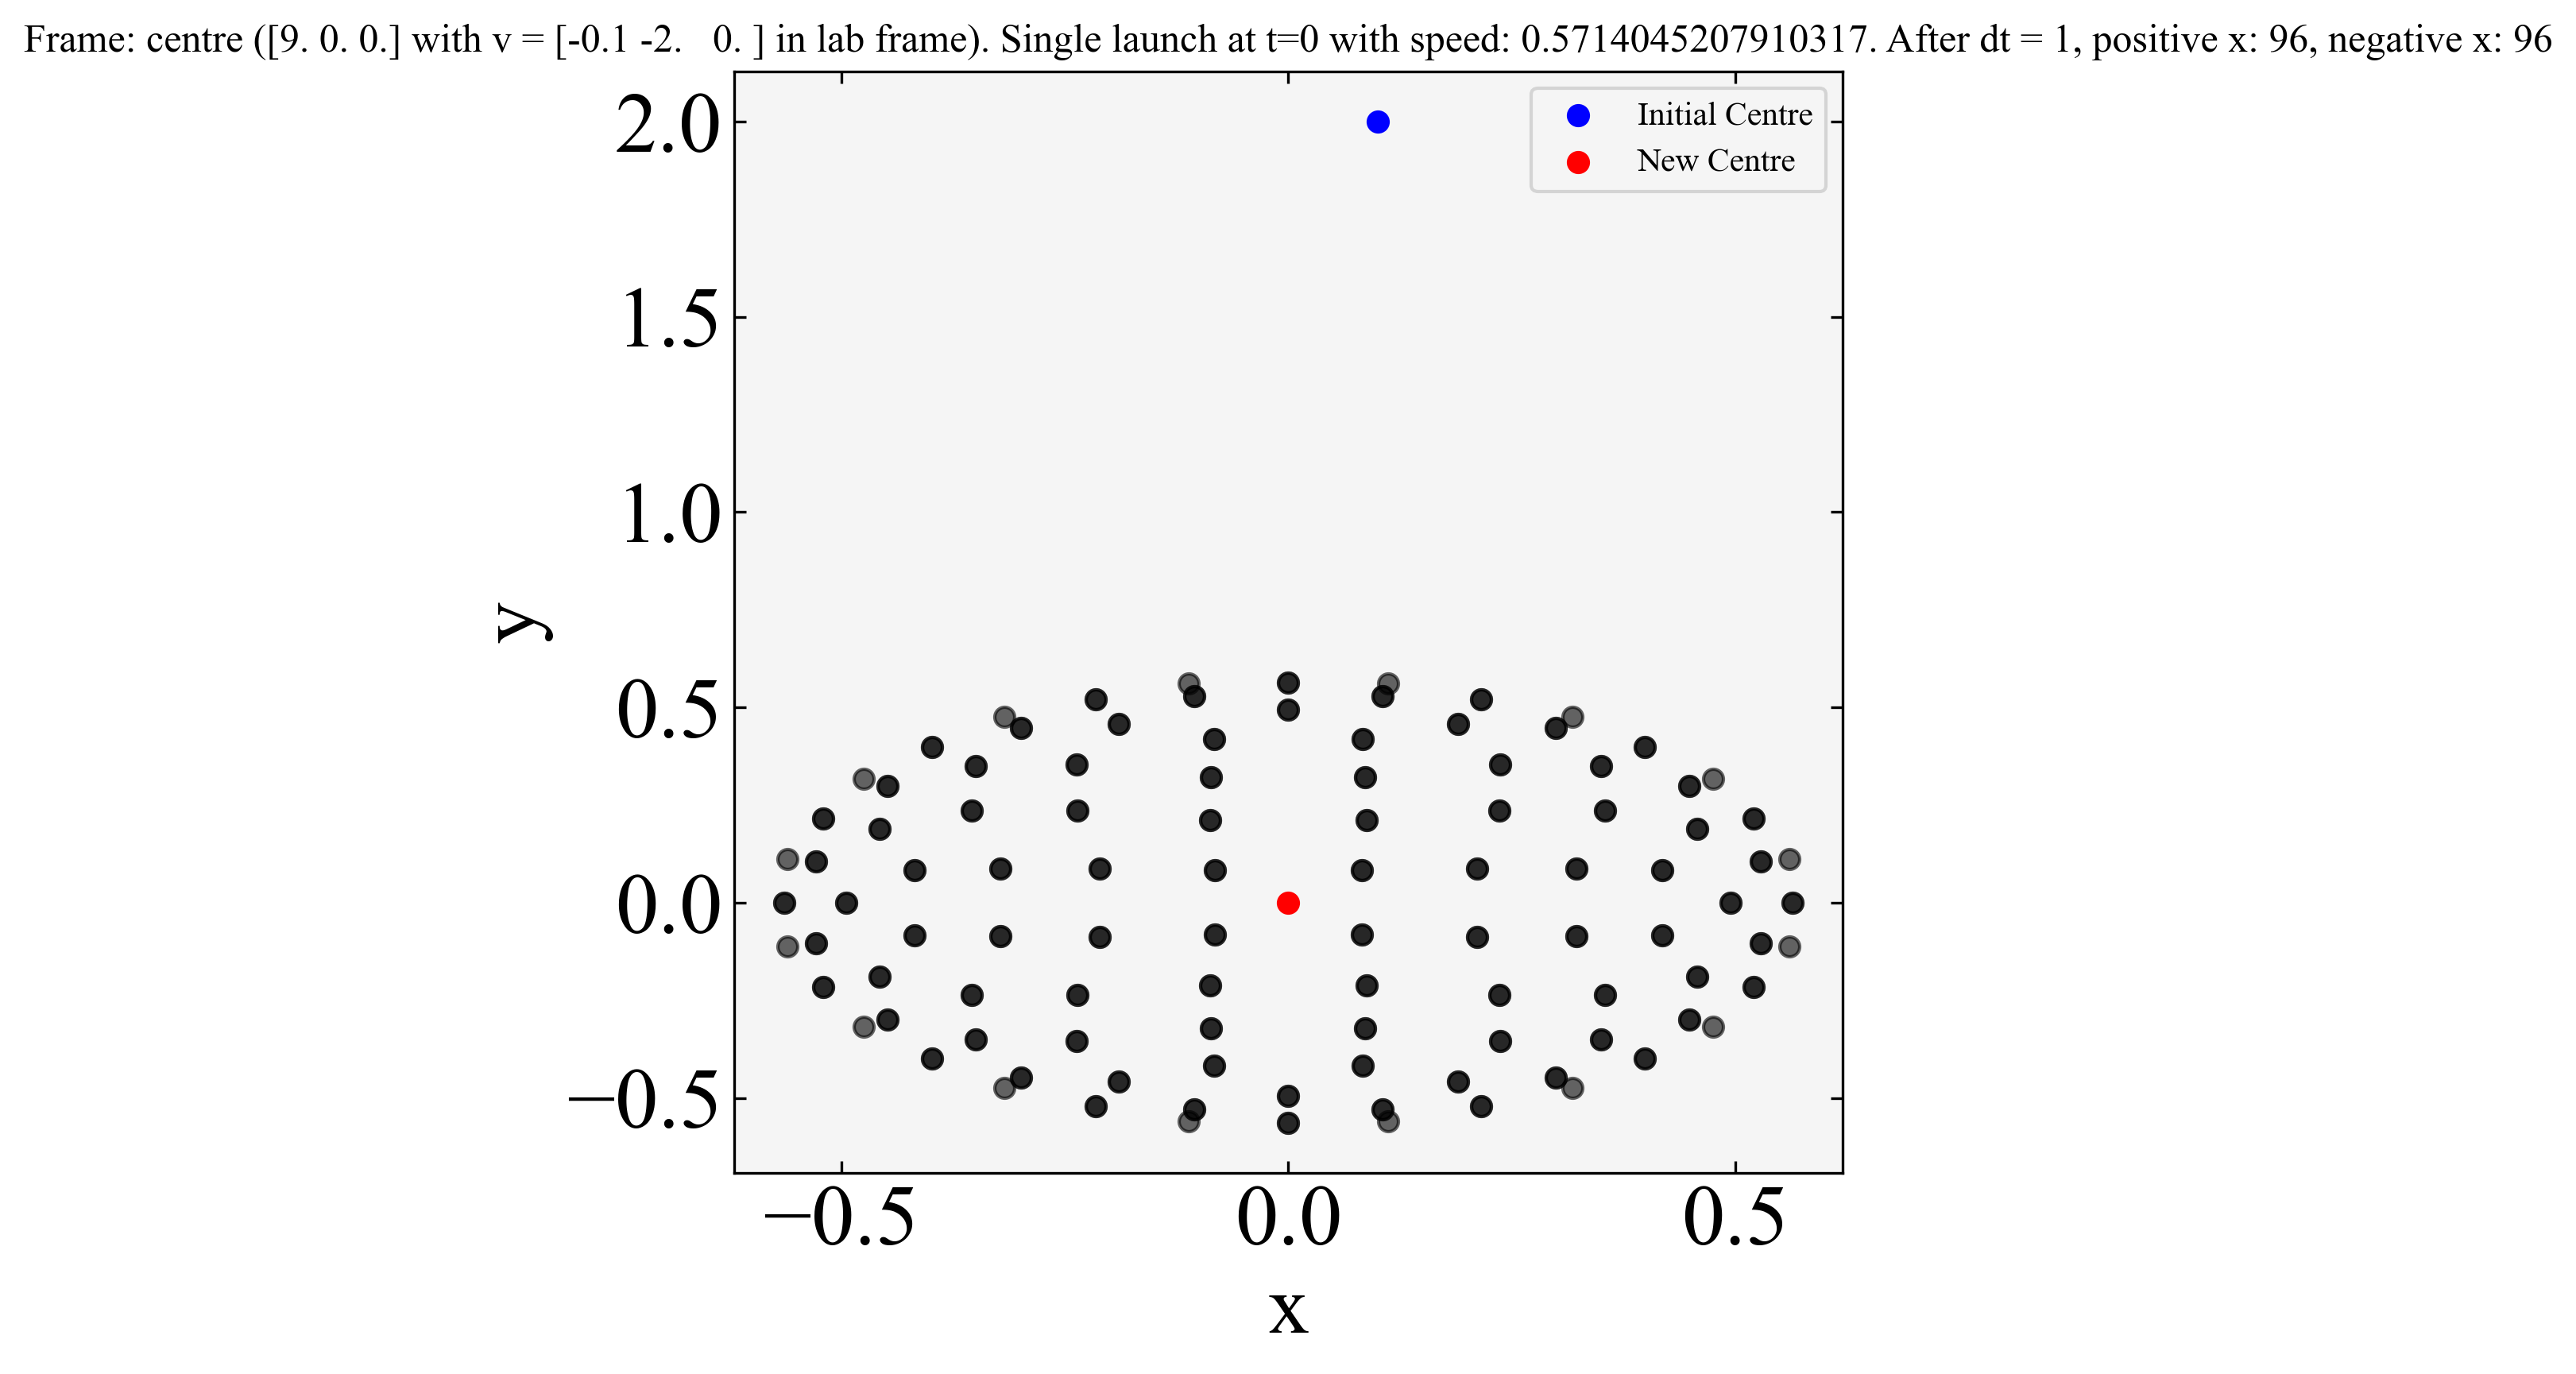

In [12]:
def launch_isotropic_particles_boost(NSIDE, speed, centre_i, dt, which_frame, visualize = False):
    """
    Gives:
    - position and velocities of isotropically launched particles from the chosen centre 
    - position and velocity of the centre with respect to the lab frame 
    after time dt
    """
    NPIX = hp.nside2npix(NSIDE)
    observers_xyz = hp.pix2vec(NSIDE, range(NPIX))
    observers_xyz = np.array(observers_xyz)
    if which_frame == 'lab' :
        coord_o_i, v_o_i = centre_i
    elif which_frame == 'centre': 
        coord_o_i = np.zeros(3)
        v_o_i = np.zeros(3)

    x_i = np.zeros(len(observers_xyz[0])) + coord_o_i[0]
    y_i = np.zeros(len(observers_xyz[1])) + coord_o_i[1]
    z_i = np.zeros(len(observers_xyz[2])) + coord_o_i[2]
    vx = speed * observers_xyz[0] + v_o_i[0]
    vy = speed * observers_xyz[1] + v_o_i[1]
    vz = speed * observers_xyz[2] + v_o_i[2]
   
    if visualize:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        scale = 4.0
        ax.quiver(x_i, y_i, z_i, vx, vy, vz, 
                length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'k', arrow_length_ratio=0.1)
        ax.scatter(coord_o_i[0], coord_o_i[1], coord_o_i[2], color='b', s=100)
        # Equal aspect ratio
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_title(f'Initial Velocity Arrows - Isotropic Launch from {coord_o_i} in {which_frame} frame')
        max_range = 10 * speed
        ax.set_xlim(-max_range - coord_o_i[0], max_range + coord_o_i[0])
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)
        ax.set_box_aspect([1, 1, 1]) 

        fig = plt.figure(figsize=(8, 8))
        plt.quiver(x_i[vz==0], y_i[vz==0], vx[vz==0], vy[vz==0],
                angles='xy', scale_units='xy', scale=2, alpha=0.6, linewidth=0.5, color = 'k')
        # it's your center
        plt.quiver(coord_o_i[0], coord_o_i[1], v_o_i[0], v_o_i[1], angles='xy', scale_units='xy', scale=2, linewidth=0.5, color = 'b')
        plt.xlim(-scale * speed, scale * speed + coord_o_i[0])
        plt.ylim(-scale * speed, scale * speed)
        plt.xlabel('x') 
        plt.ylabel('y')
        plt.title(f'Initial Velocity Arrows - Isotropic Launch from {coord_o_i} in {which_frame} frame (XY Plane)')
        plt.tight_layout()

    # Start at the origin and move ballistically for time dt
    x = x_i + vx * dt
    y = y_i + vy * dt
    z = z_i + vz * dt
    v_o = centre_i[1]
    coord_o = centre_i[0] + v_o * dt

    pos = np.column_stack((x, y, z))
    vel = np.column_stack((vx, vy, vz))

    if visualize:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        scale = 4.0
        ax.quiver(x, y, z, vx, vy, vz, 
                length=scale, normalize=False, alpha=0.6, linewidth=0.5, color = 'k', arrow_length_ratio=0.1)
        if which_frame == 'lab':
            ax.scatter(coord_o_i[0], coord_o_i[1], coord_o_i[2], color='b', s=100, label='Initial Centre')
            ax.scatter(coord_o[0], coord_o[1], coord_o[2], color='r', s=100, label='New Centre')
        else:
            ax.scatter(centre_i[0][0]-coord_o[0], centre_i[0][1]-coord_o[1], centre_i[0][2]-coord_o[2], color='b', s=100, label='Initial Centre')
            # the new centre is 0
            ax.scatter(0, 0, 0, color='r', s=100, label='New Centre')
        ax.legend()
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('z')
        ax.set_xlim(-max_range, max_range + coord_o_i[0])
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)
        ax.set_title(f'Frame: {which_frame}, after dt = {dt}, positive x: {len(x[x>0])}, negative x: {len(x[x<0])}')
        ax.set_box_aspect([1, 1, 1]) 

    return pos, vel, coord_o, v_o

which_frame = 'centre'  # 'lab' or 'centre'
single_time = 1

pos, vel, coord_o, v_o = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre, dt=single_time, which_frame = which_frame, visualize=True) 
xN = pos[:, 0]
r_coord = np.linalg.norm(pos, axis=1)
# the launch is at t=0. You want to know Npos and Nneg with resepct to the new orgin in case of "centre" 
# Npos= len(xN[xN > 0]) if which_frame == 'lab' else len(xN[xN > centre[1][0] * single_time]) 
# Nneg= len(xN[xN < 0]) if which_frame == 'lab' else len(xN[xN < centre[1][0] * single_time])
Npos= len(xN[xN > 0]) 
Nneg= len(xN[xN < 0]) 
plt.figure(figsize=(6,6))
plt.scatter(pos[:, 0], pos[:, 1], alpha=0.6, color='k')
if which_frame == 'centre':
    plt.scatter(centre[0][0]-coord_o[0], centre[0][1]-coord_o[1], color='b', label='Initial Centre')
    plt.scatter(0, 0, color='r', label='New Centre')
else:
    plt.scatter(centre[0][0], centre[0][1], color='b', label='Initial Centre')
    plt.scatter(coord_o[0], coord_o[1], color='r', label='New Centre')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title(f'Frame: {which_frame} ({centre[0]} with v = {centre[1]} in lab frame). Single launch at t=0 with speed: {speed}. After dt = {single_time}, positive x: {Npos}, negative x: {Nneg}')

print(f'Single launch at t=0 with speed: {speed}. Frame: {which_frame}, central point in {centre[0]} with v = {centre[1]}')
print(f'After dt = {single_time}, positive x: {Npos}, negative x: {Nneg}')

v_r, _, _ = op.to_spherical_components(vel[:,0], vel[:,1], vel[:,2], pos[:,0], pos[:,1], pos[:,2])
print(f'Positive x: {len(xN[xN>0])}, Negative x: {len(xN[xN<0])} after dt = {single_time}')

# orbital_energies = orbital_energy(r_coord, v_r)
# plt.figure(figsize=(6,6))
# plt.scatter(r_coord, orbital_energies, alpha=0.6, color='k')
# plt.xlabel('Radial Distance')
# plt.ylabel('Orbital Energy')
# r_thres = r_lim_unb(v_r)
# print(r_coord[orbital_energies>0]/r_thres[orbital_energies>0])


Text(0.5, 1.0, 'Frame: lab')

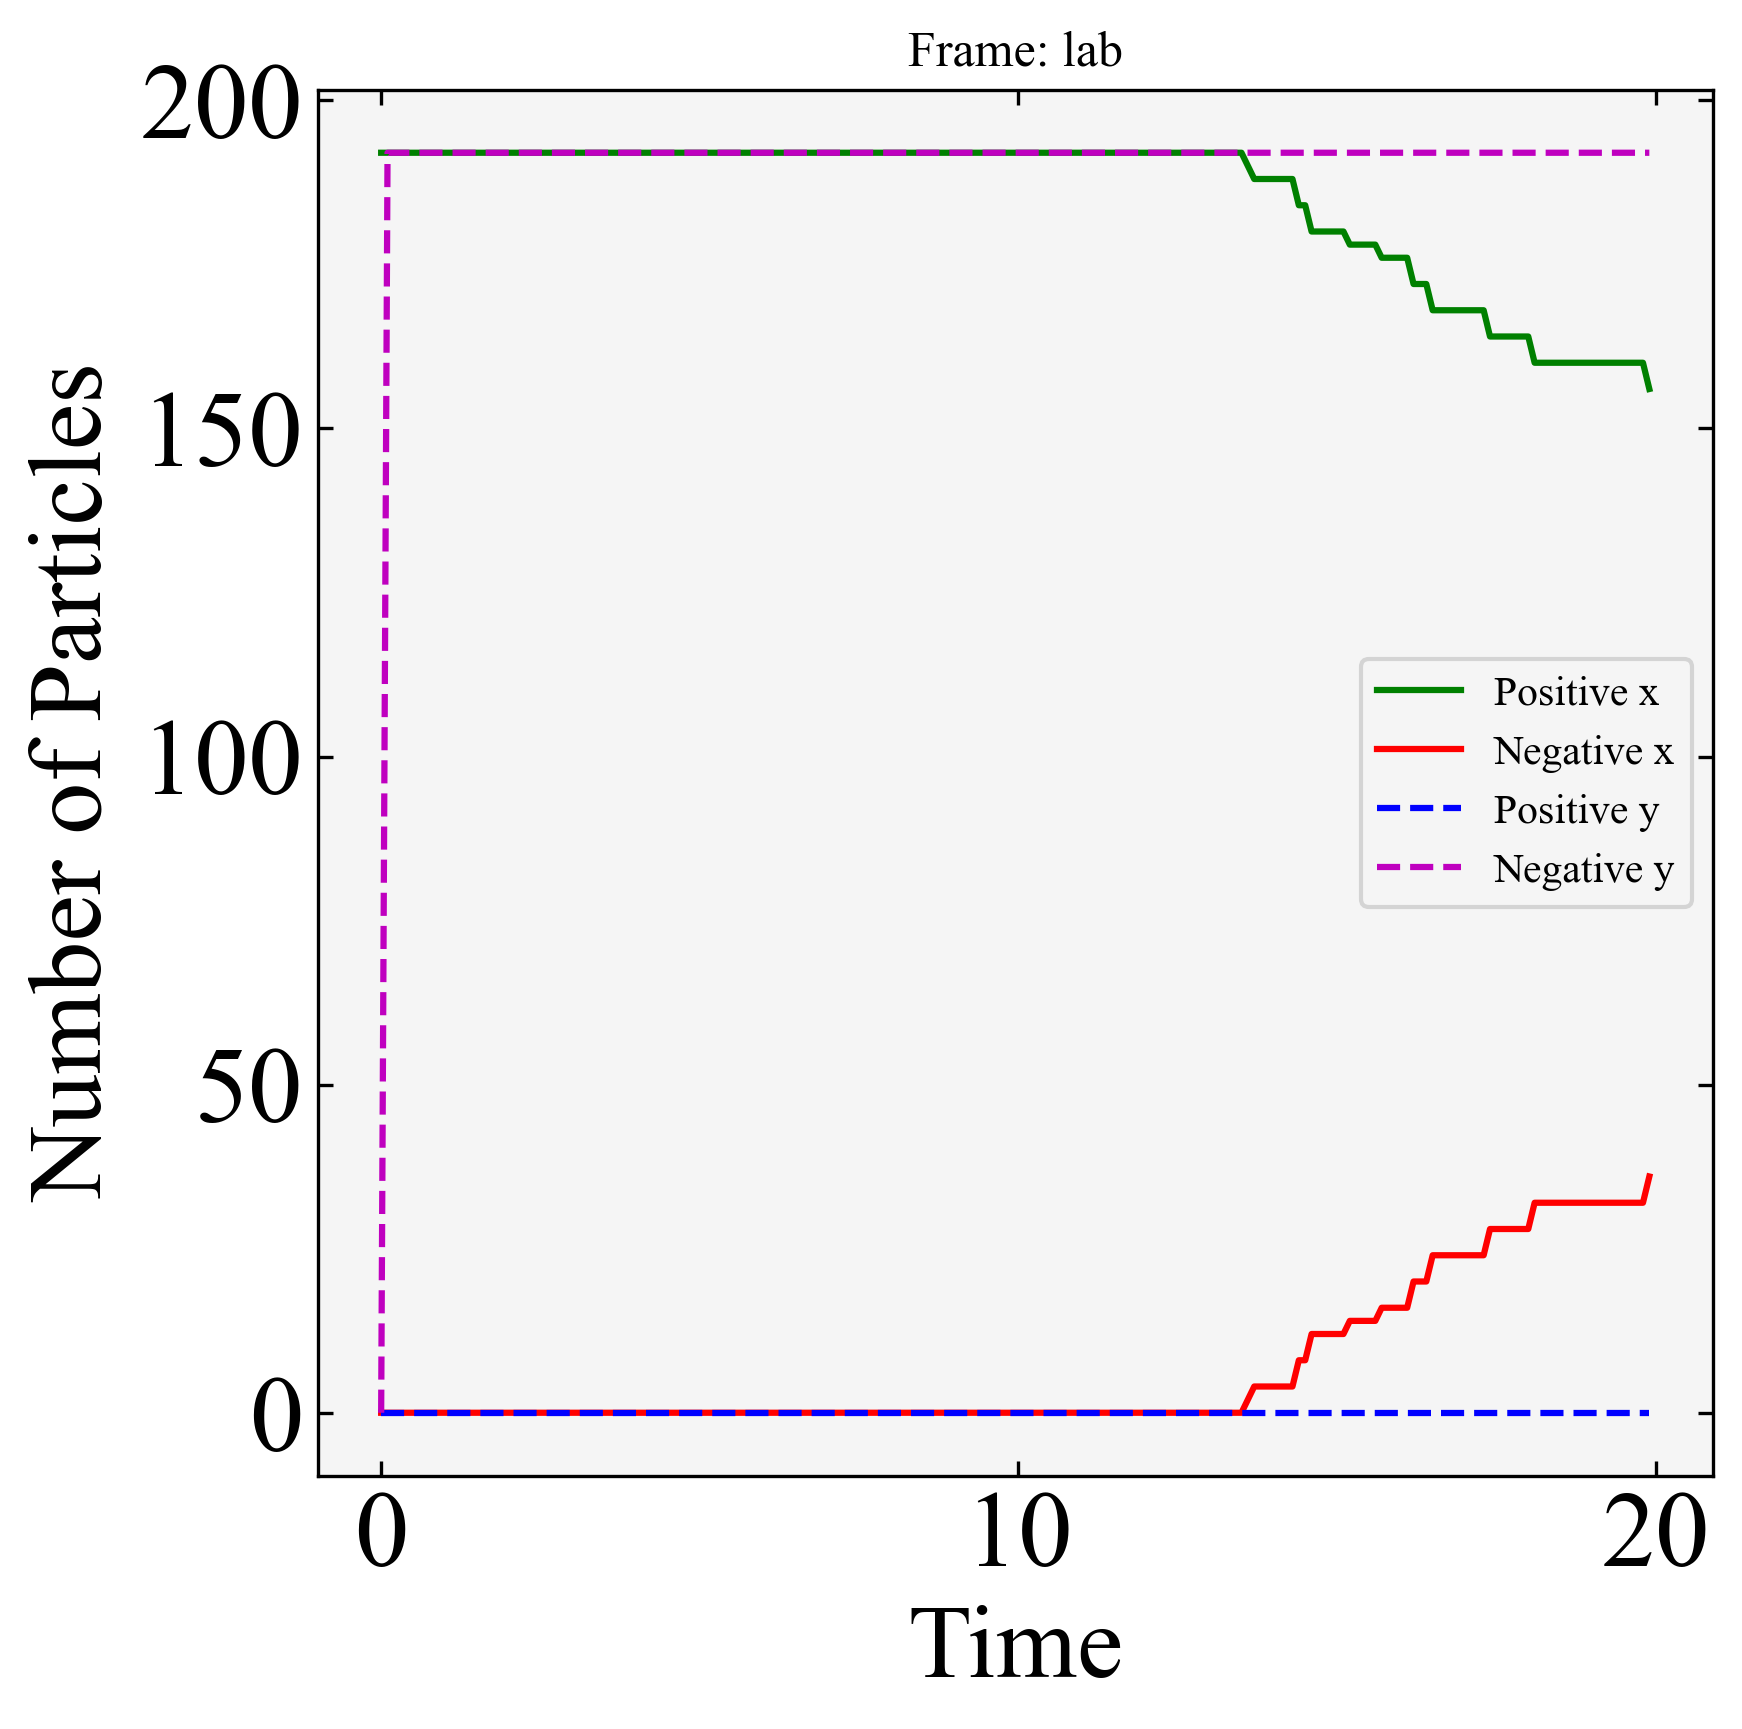

In [13]:
which_frame = 'lab'  # 'lab' or 'centre'

Nxpos = np.zeros(len(times))
Nxneg = np.zeros(len(times))
Nypos = np.zeros(len(times))
Nyneg = np.zeros(len(times))
for i, time in enumerate(times):
    pos, vel, coord_o, v_o = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre, dt=time, which_frame = which_frame, visualize=False)
    xN = pos[:, 0]
    xN = xN[np.abs(xN) > 1e-10]  # to avoid counting particles that are exactly on the y-axis
    Nxpos[i] = len(xN[xN > 0])
    Nxneg[i] = len(xN[xN < 0]) 
    yN = pos[:, 1]
    yN = yN[np.abs(yN) > 1e-10]  # to avoid counting particles that are exactly on the x-axis
    Nypos[i] = len(yN[yN > 0])
    Nyneg[i] = len(yN[yN < 0])

plt.figure(figsize=(6,6))
plt.plot(times, Nxpos, label='Positive x',  color='g')
plt.plot(times, Nxneg, label='Negative x', color='r')

plt.plot(times, Nypos, label='Positive y',  color='b', ls = '--')   
plt.plot(times, Nyneg, label='Negative y', color='m', ls = '--')
if which_frame == 'lab':
    time_first_cross = centre[0][0]/(np.abs(centre[1][0])+speed) # time at which the first particle crosses x=0, which is the one with speed directed completely in -x
    time_o_cross = centre[0][0]/np.abs(centre[1][0])  # time at which the centre crosses x=0
    # plt.axvline(time_o_cross, color='k', linestyle=':', label=f'Crossing time of centre at x=0')
    # plt.axvline(time_first_cross, color='m', linestyle=':', label=f'First crossing time of centre at x=0 by particles')
plt.xlabel('Time')
plt.ylabel('Number of Particles')
plt.legend()
plt.title(f'Frame: {which_frame}')


<Figure size 2100x1500 with 0 Axes>

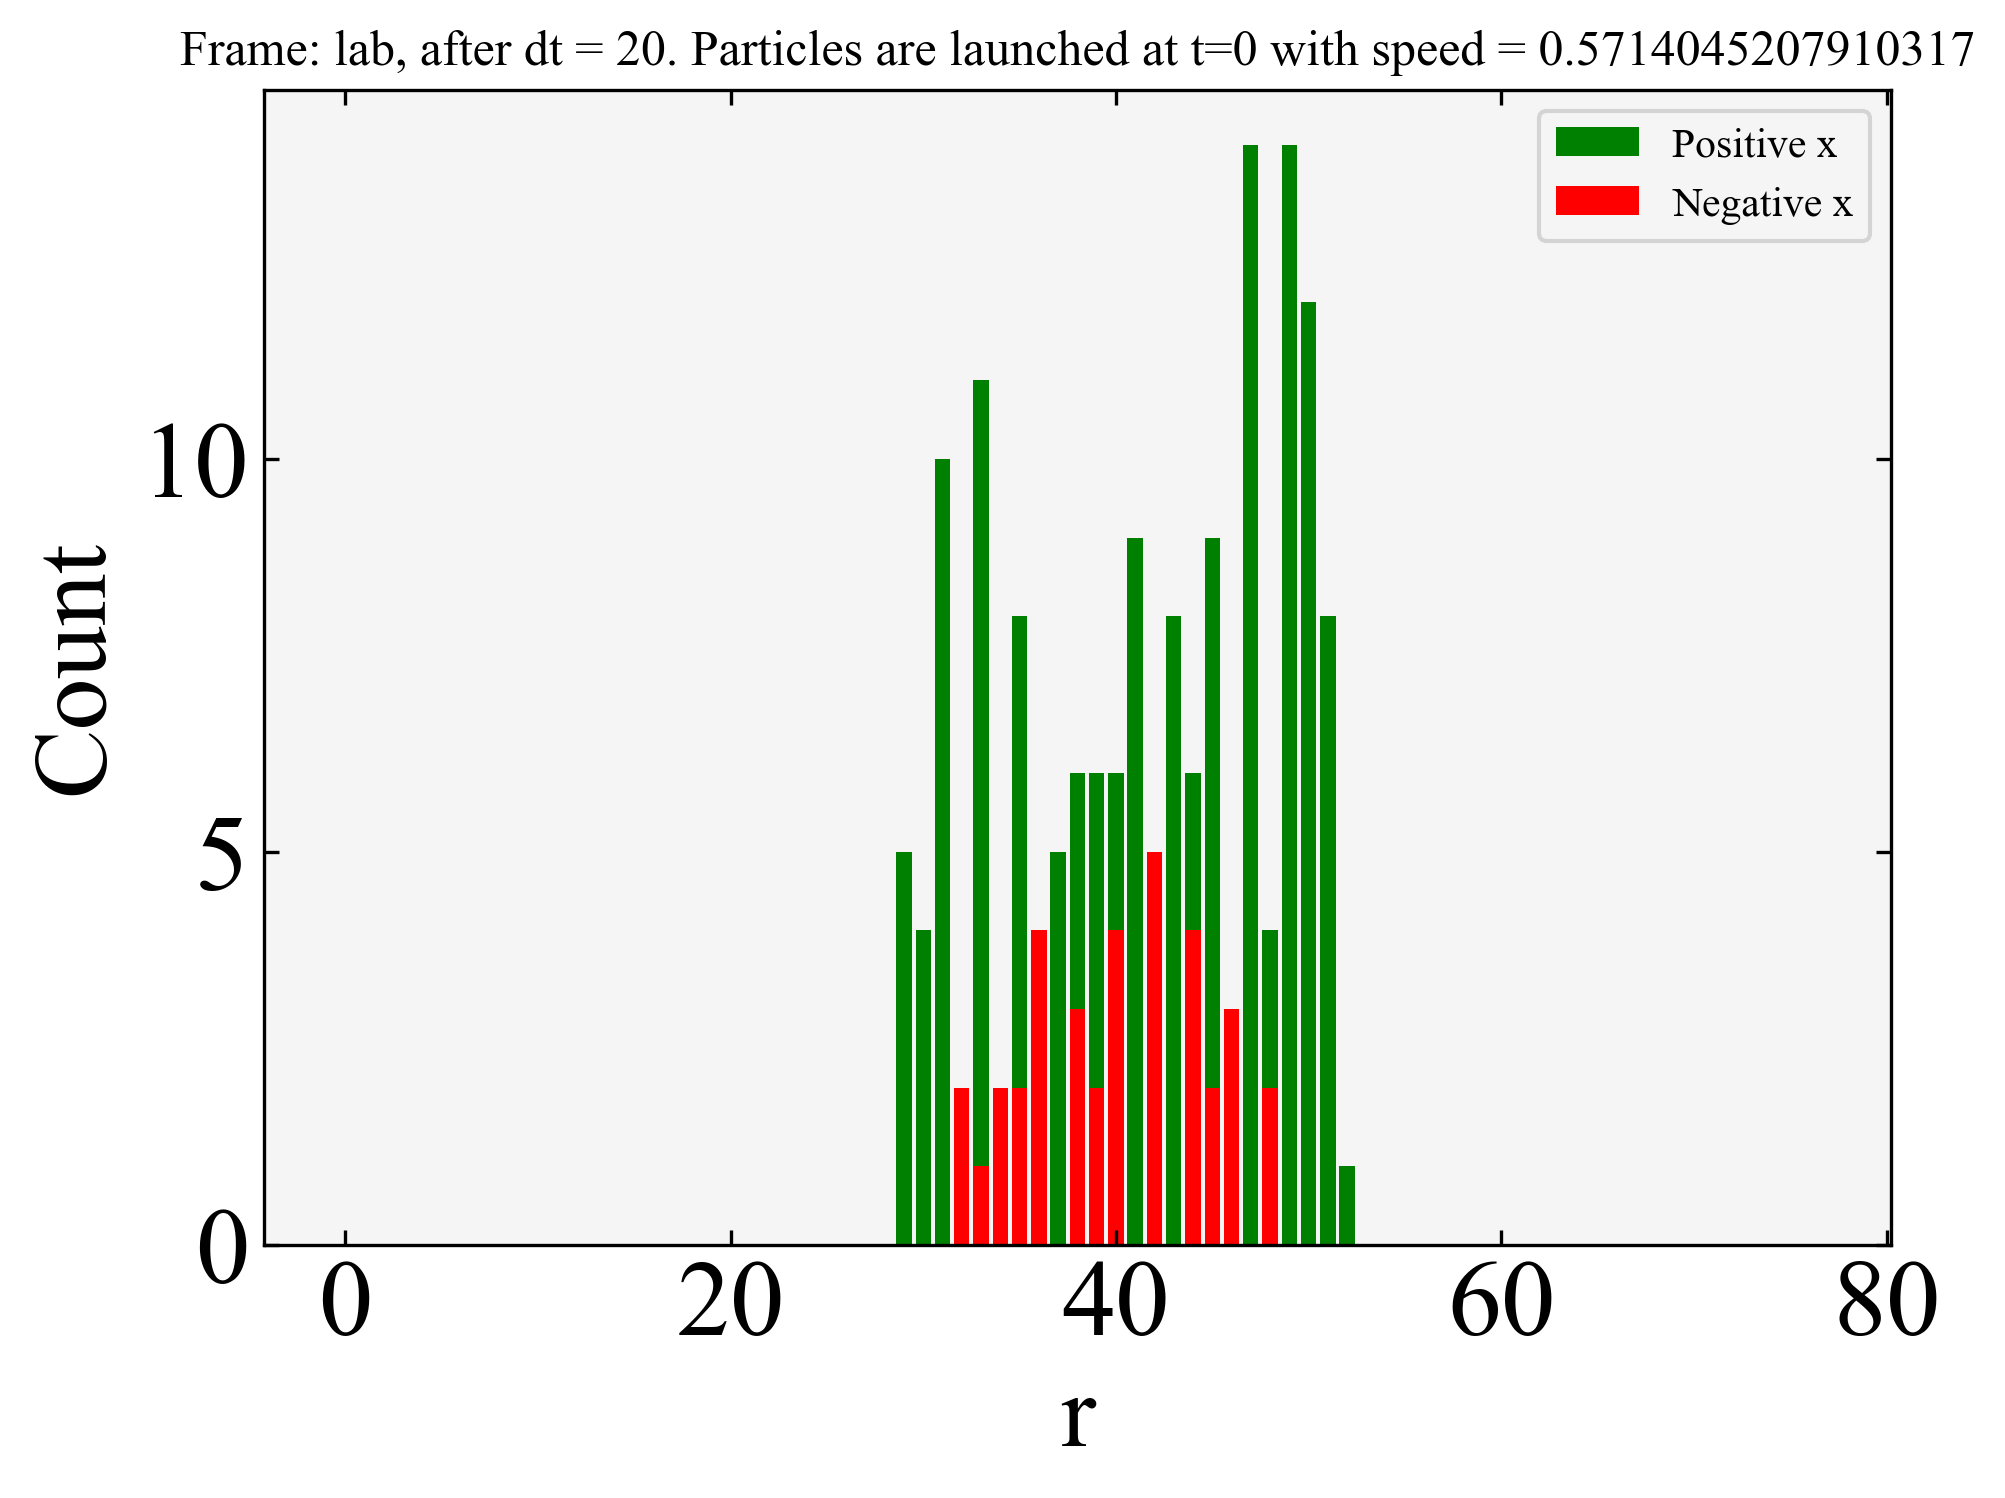

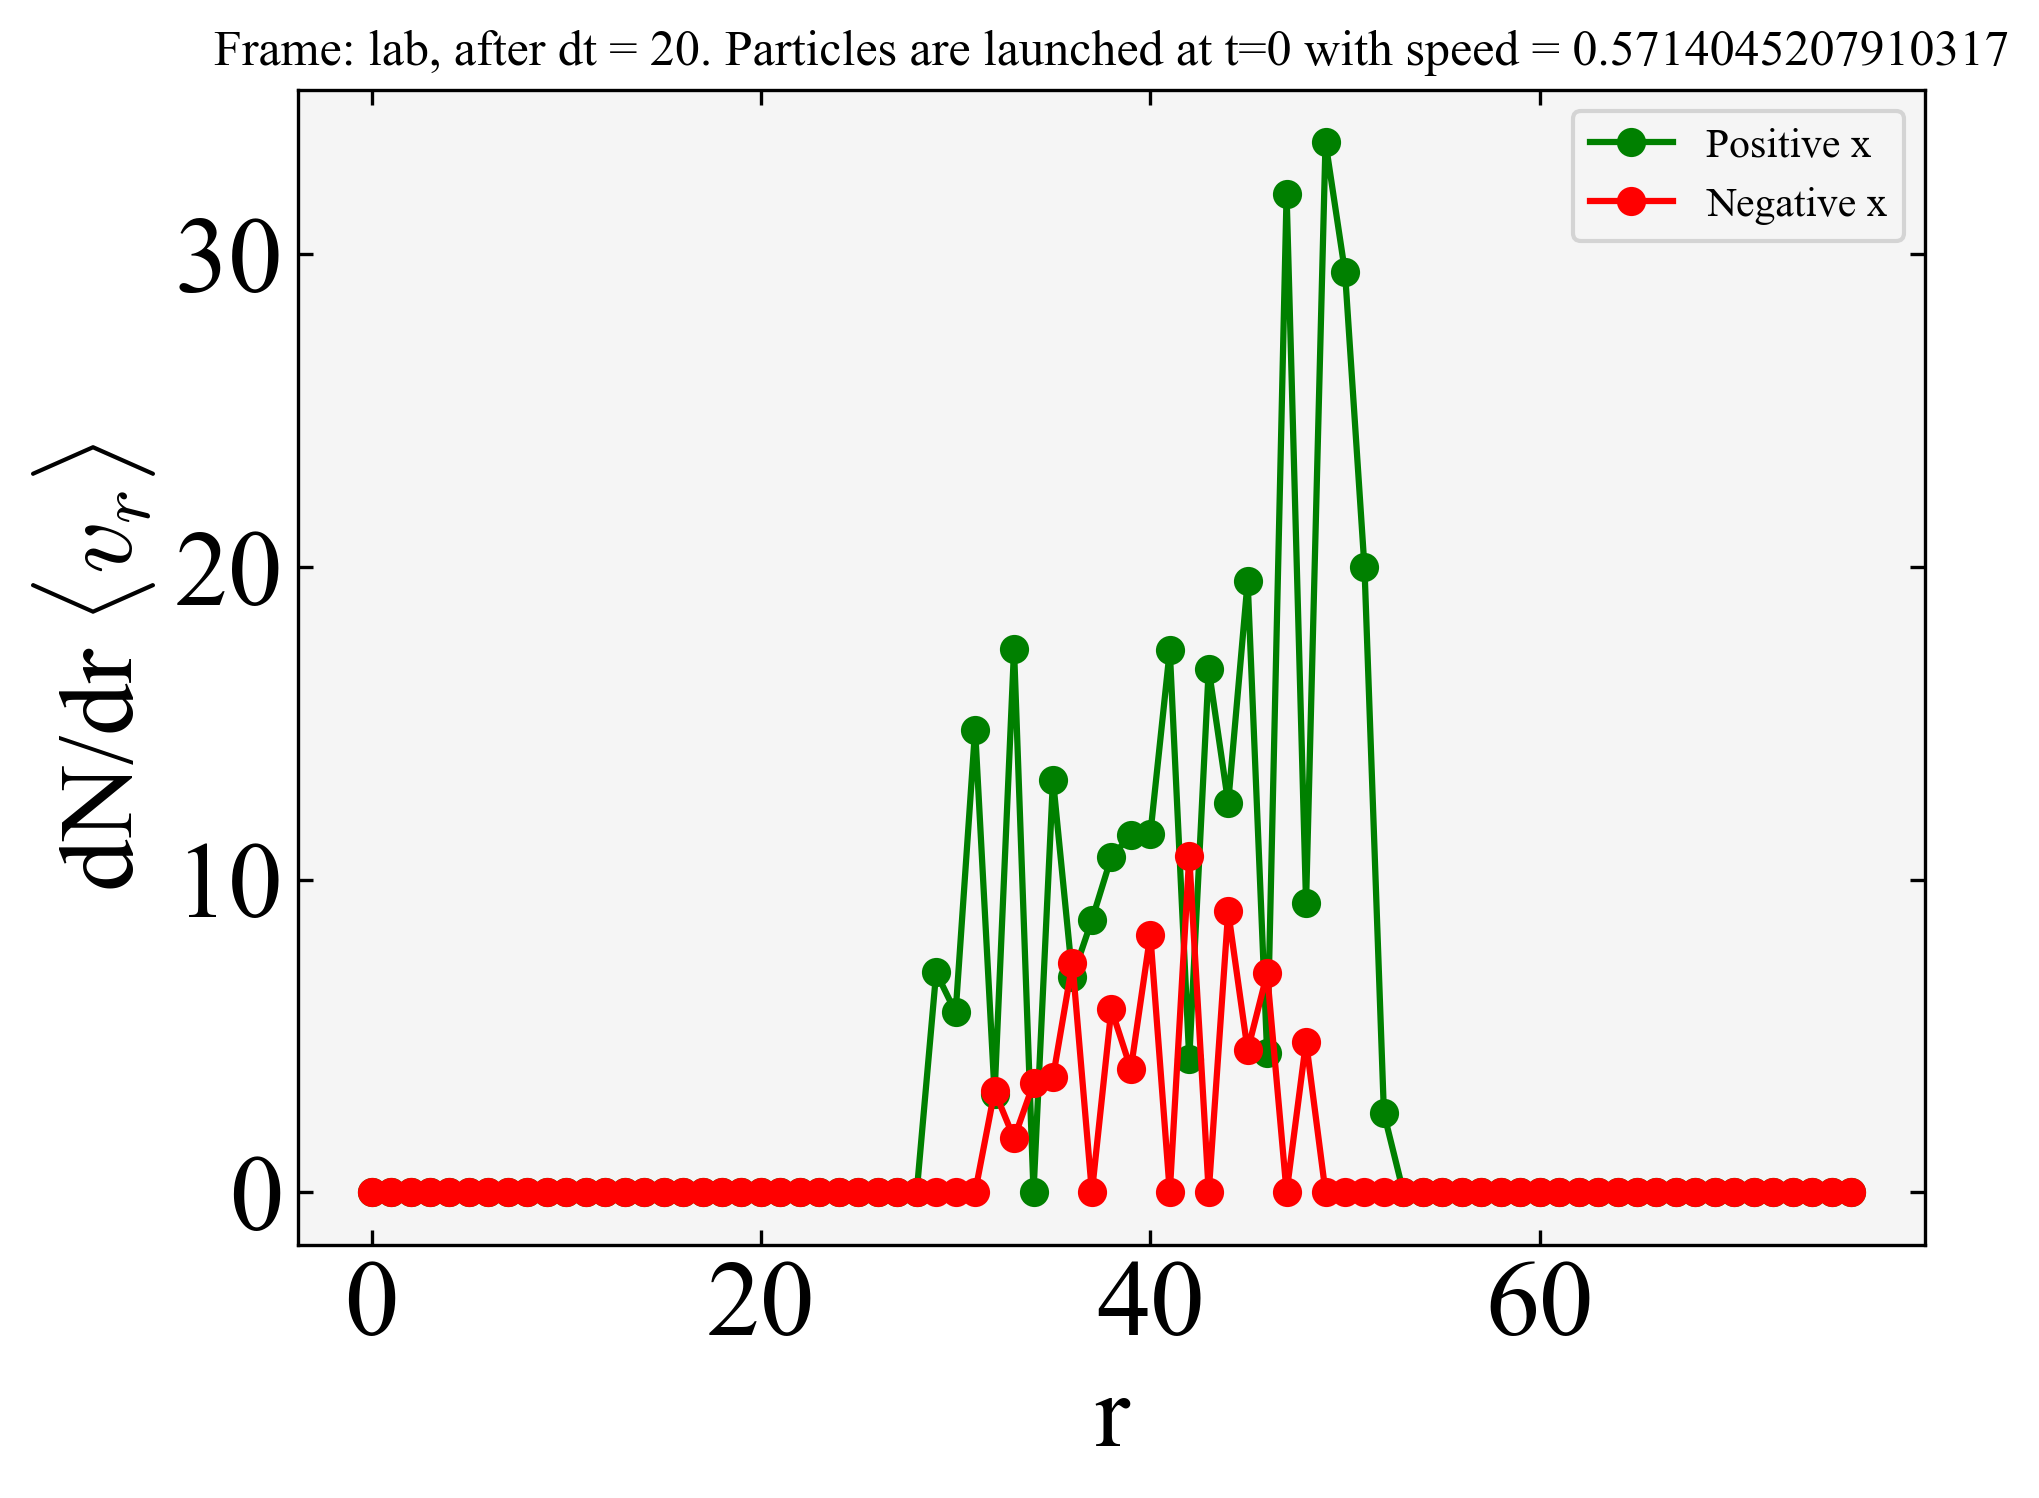

In [14]:
which_frame = 'lab'  # 'lab' or 'centre'
single_time = 20
rmin = 0
rmax = 1.5 * (speed+np.linalg.norm(centre[1])) * single_time 
bins_r = 1 #0.5 * single_time * min(speed, np.linalg.norm(centre[1]))
r_bins = np.arange(rmin, rmax, bins_r)
plt.figure(figsize=(7,5))

pos, vel, coord_o, v_o = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre, dt=single_time, which_frame = which_frame, visualize=False) #True if i == 10 else False)
r_all = np.linalg.norm(pos, axis=1)

xN = pos[:, 0]
plt.figure(figsize=(7,5))
# finding r for the particles launched in the x direction
if which_frame == 'lab': 
    # the outer is the one at pi with resepct to the radial direction of the centre
    NPIX = hp.nside2npix(N)
    observers_xyz = hp.pix2vec(N, range(NPIX))
    observers_xyz = np.array(observers_xyz)
    # print(np.repeat([centre[1]], 192, axis=0))
    dot_prod = np.dot(centre[0], np.transpose(vel)) # the one moving in the -x direction
    idx_in = np.argmin(dot_prod)
    idx_out = np.argmax(dot_prod)
    # r_inner = np.linalg.norm(centre[0]+vel[idx_in] * single_time) # -speed because goes in -x direction
    # r_outer = np.linalg.norm(centre[0]+vel[idx_out] * single_time) # the one moving on the y direction, since they x is not shifted
if which_frame == 'centre': 
    r_inner = speed * single_time 
    r_outer = r_inner 
    plt.axvline(r_outer, color='g', linestyle='--', label='Expected r for most positive x-launched ')
    plt.axvline(r_inner, color='r', linestyle=':', label='Expected r for most negative x-launched ')
v_r, _, _ = op.to_spherical_components(vel[:,0], vel[:,1], vel[:,2], pos[:,0], pos[:,1], pos[:,2])

r_all = r_all[np.abs(xN) > 1e-10]  
v_r = v_r[np.abs(xN) > 1e-10]
xN = xN[np.abs(xN) > 1e-10]  
Rpos= r_all[xN > 0] 
Rneg= r_all[xN < 0] 
vr_pos = v_r[xN > 0]
vr_neg = v_r[xN < 0]

binRpos, r_bins = np.histogram(Rpos, bins=r_bins)
binRneg, r_bins = np.histogram(Rneg, bins=r_bins)

plt.bar(r_bins[:-1], binRpos, label='Positive x', color='g')
plt.bar(r_bins[:-1], binRneg,  label='Negative x', color='r')
plt.xlabel('r')
plt.ylabel('Count')
plt.title(f'Frame: {which_frame}, after dt = {single_time}. Particles are launched at t=0 with speed = {speed}')
plt.legend()

Nvr_pos = np.zeros_like(r_bins[:-1])
Nvr_neg = np.zeros_like(r_bins[:-1])
for i, r in enumerate(r_bins[:-1]):
    # check where Rpos is between r and r+bins_r
    cut_count_pos = (Rpos >= r) & (Rpos < r_bins[i+1])
    cut_count_neg = (Rneg >= r) & (Rneg < r_bins[i+1])
    Nvr_pos[i] = len(Rpos[cut_count_pos])* np.mean(vr_pos[cut_count_pos]) if len(Rpos[cut_count_pos]) > 0 else 0
    Nvr_neg[i] = len(Rneg[cut_count_neg])* np.mean(vr_neg[cut_count_neg]) if len(Rneg[cut_count_neg]) > 0 else 0
plt.figure(figsize=(7,5))
plt.plot(r_bins[:-1], Nvr_pos, '-o', label='Positive x', color='g')
plt.plot(r_bins[:-1], Nvr_neg, '-o', label='Negative x', color='r')
plt.xlabel('r')
plt.ylabel(r'dN/dr $\langle v_r \rangle$')
plt.title(f'Frame: {which_frame}, after dt = {single_time}. Particles are launched at t=0 with speed = {speed}')
plt.legend()



Positive x: 36728, Negative x: 1672 after dt = 20.0


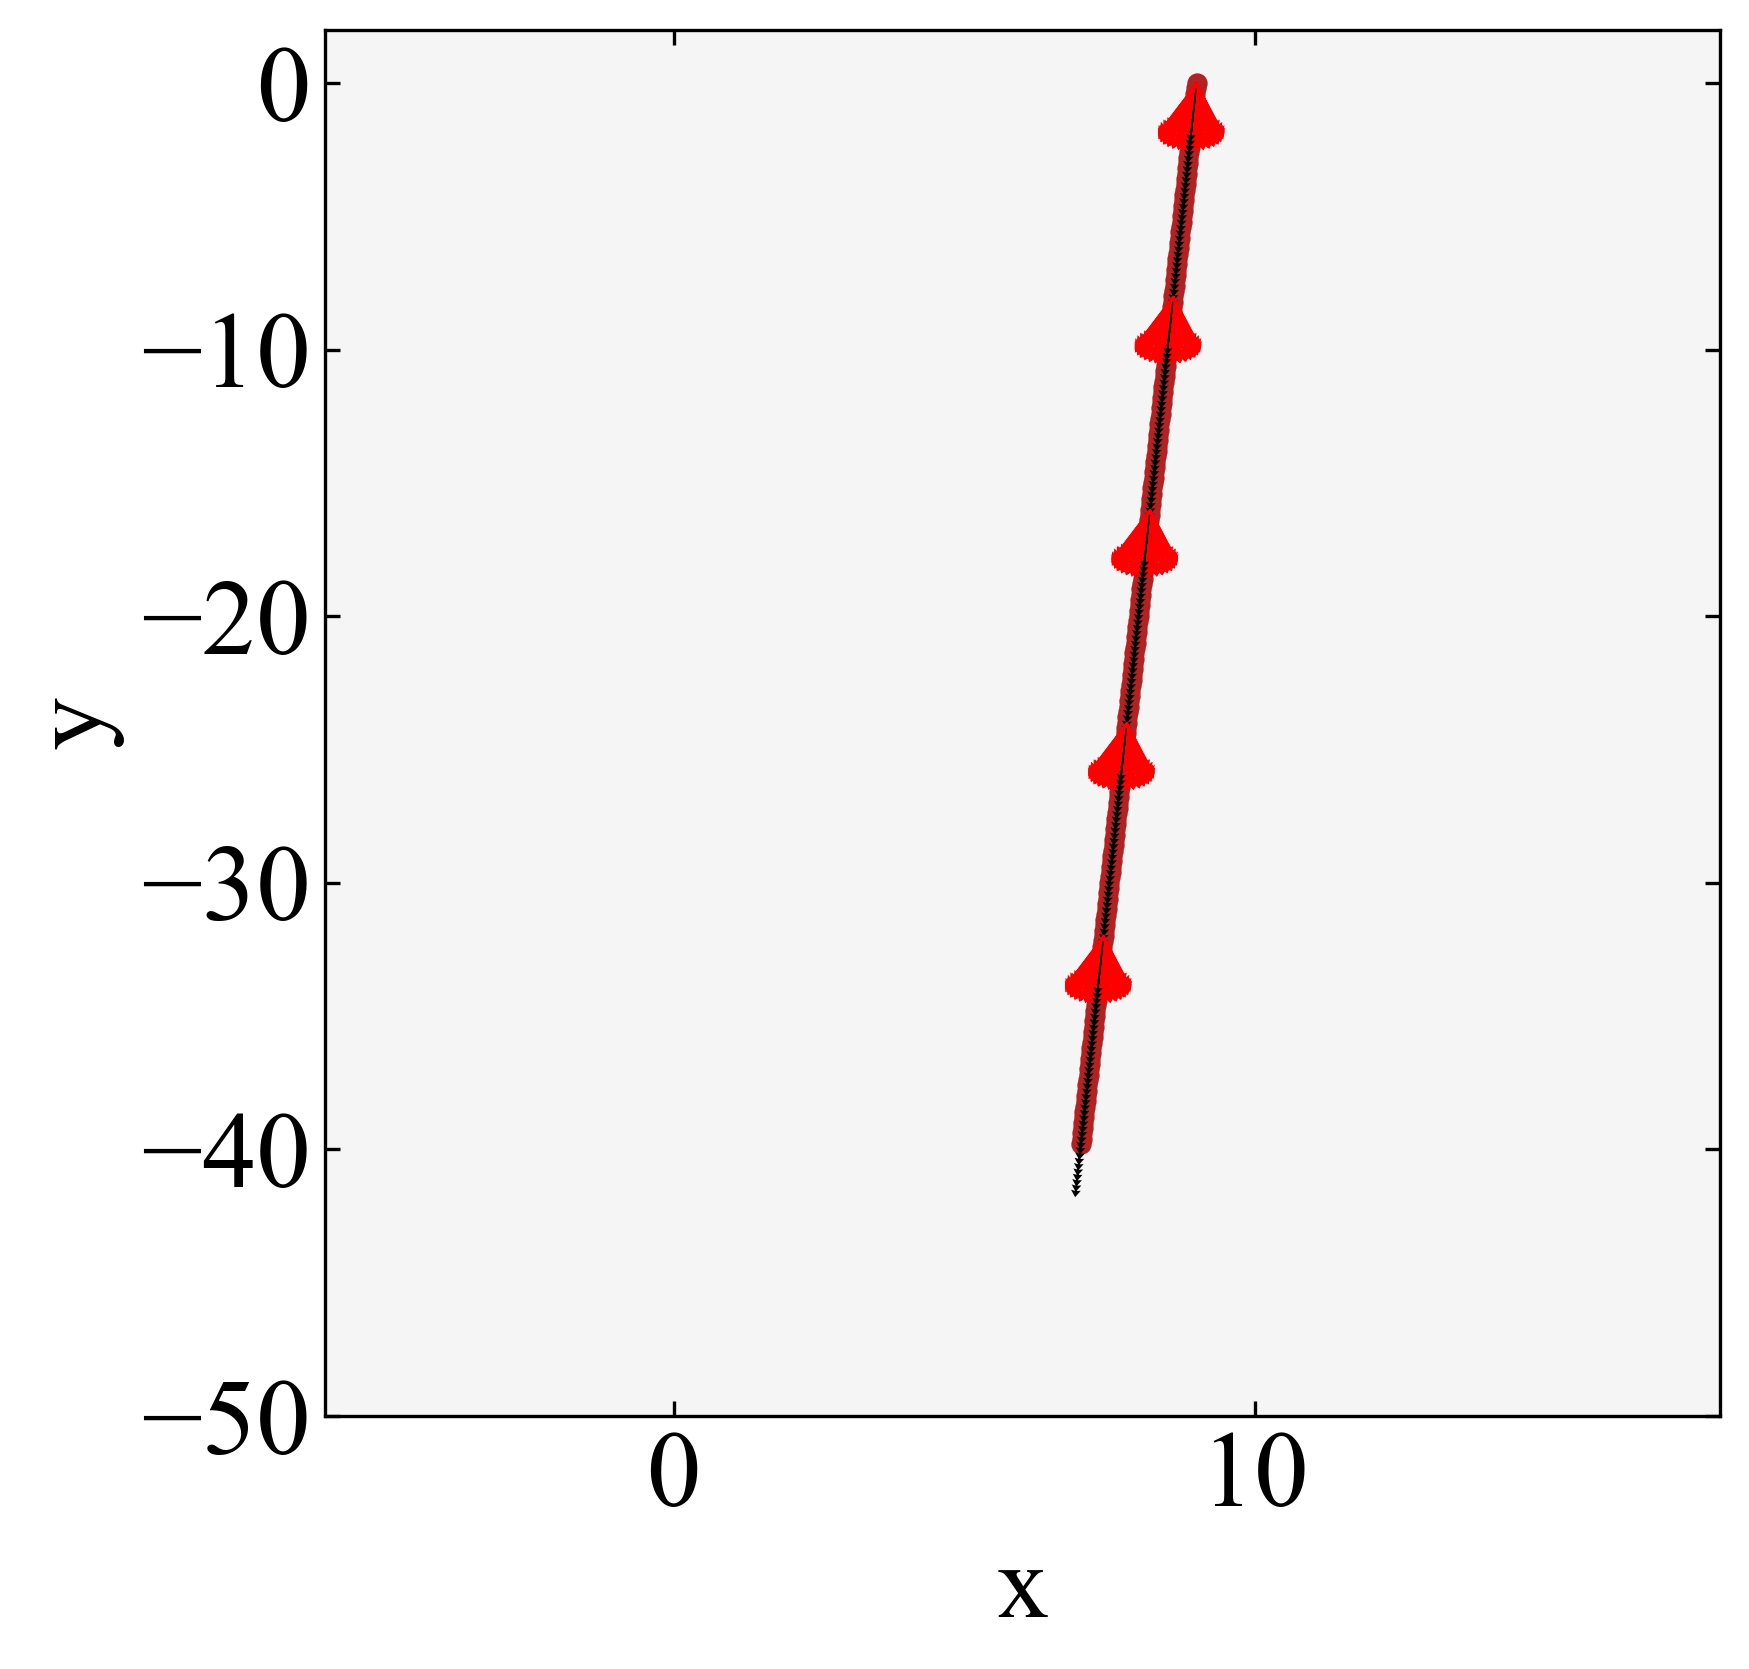

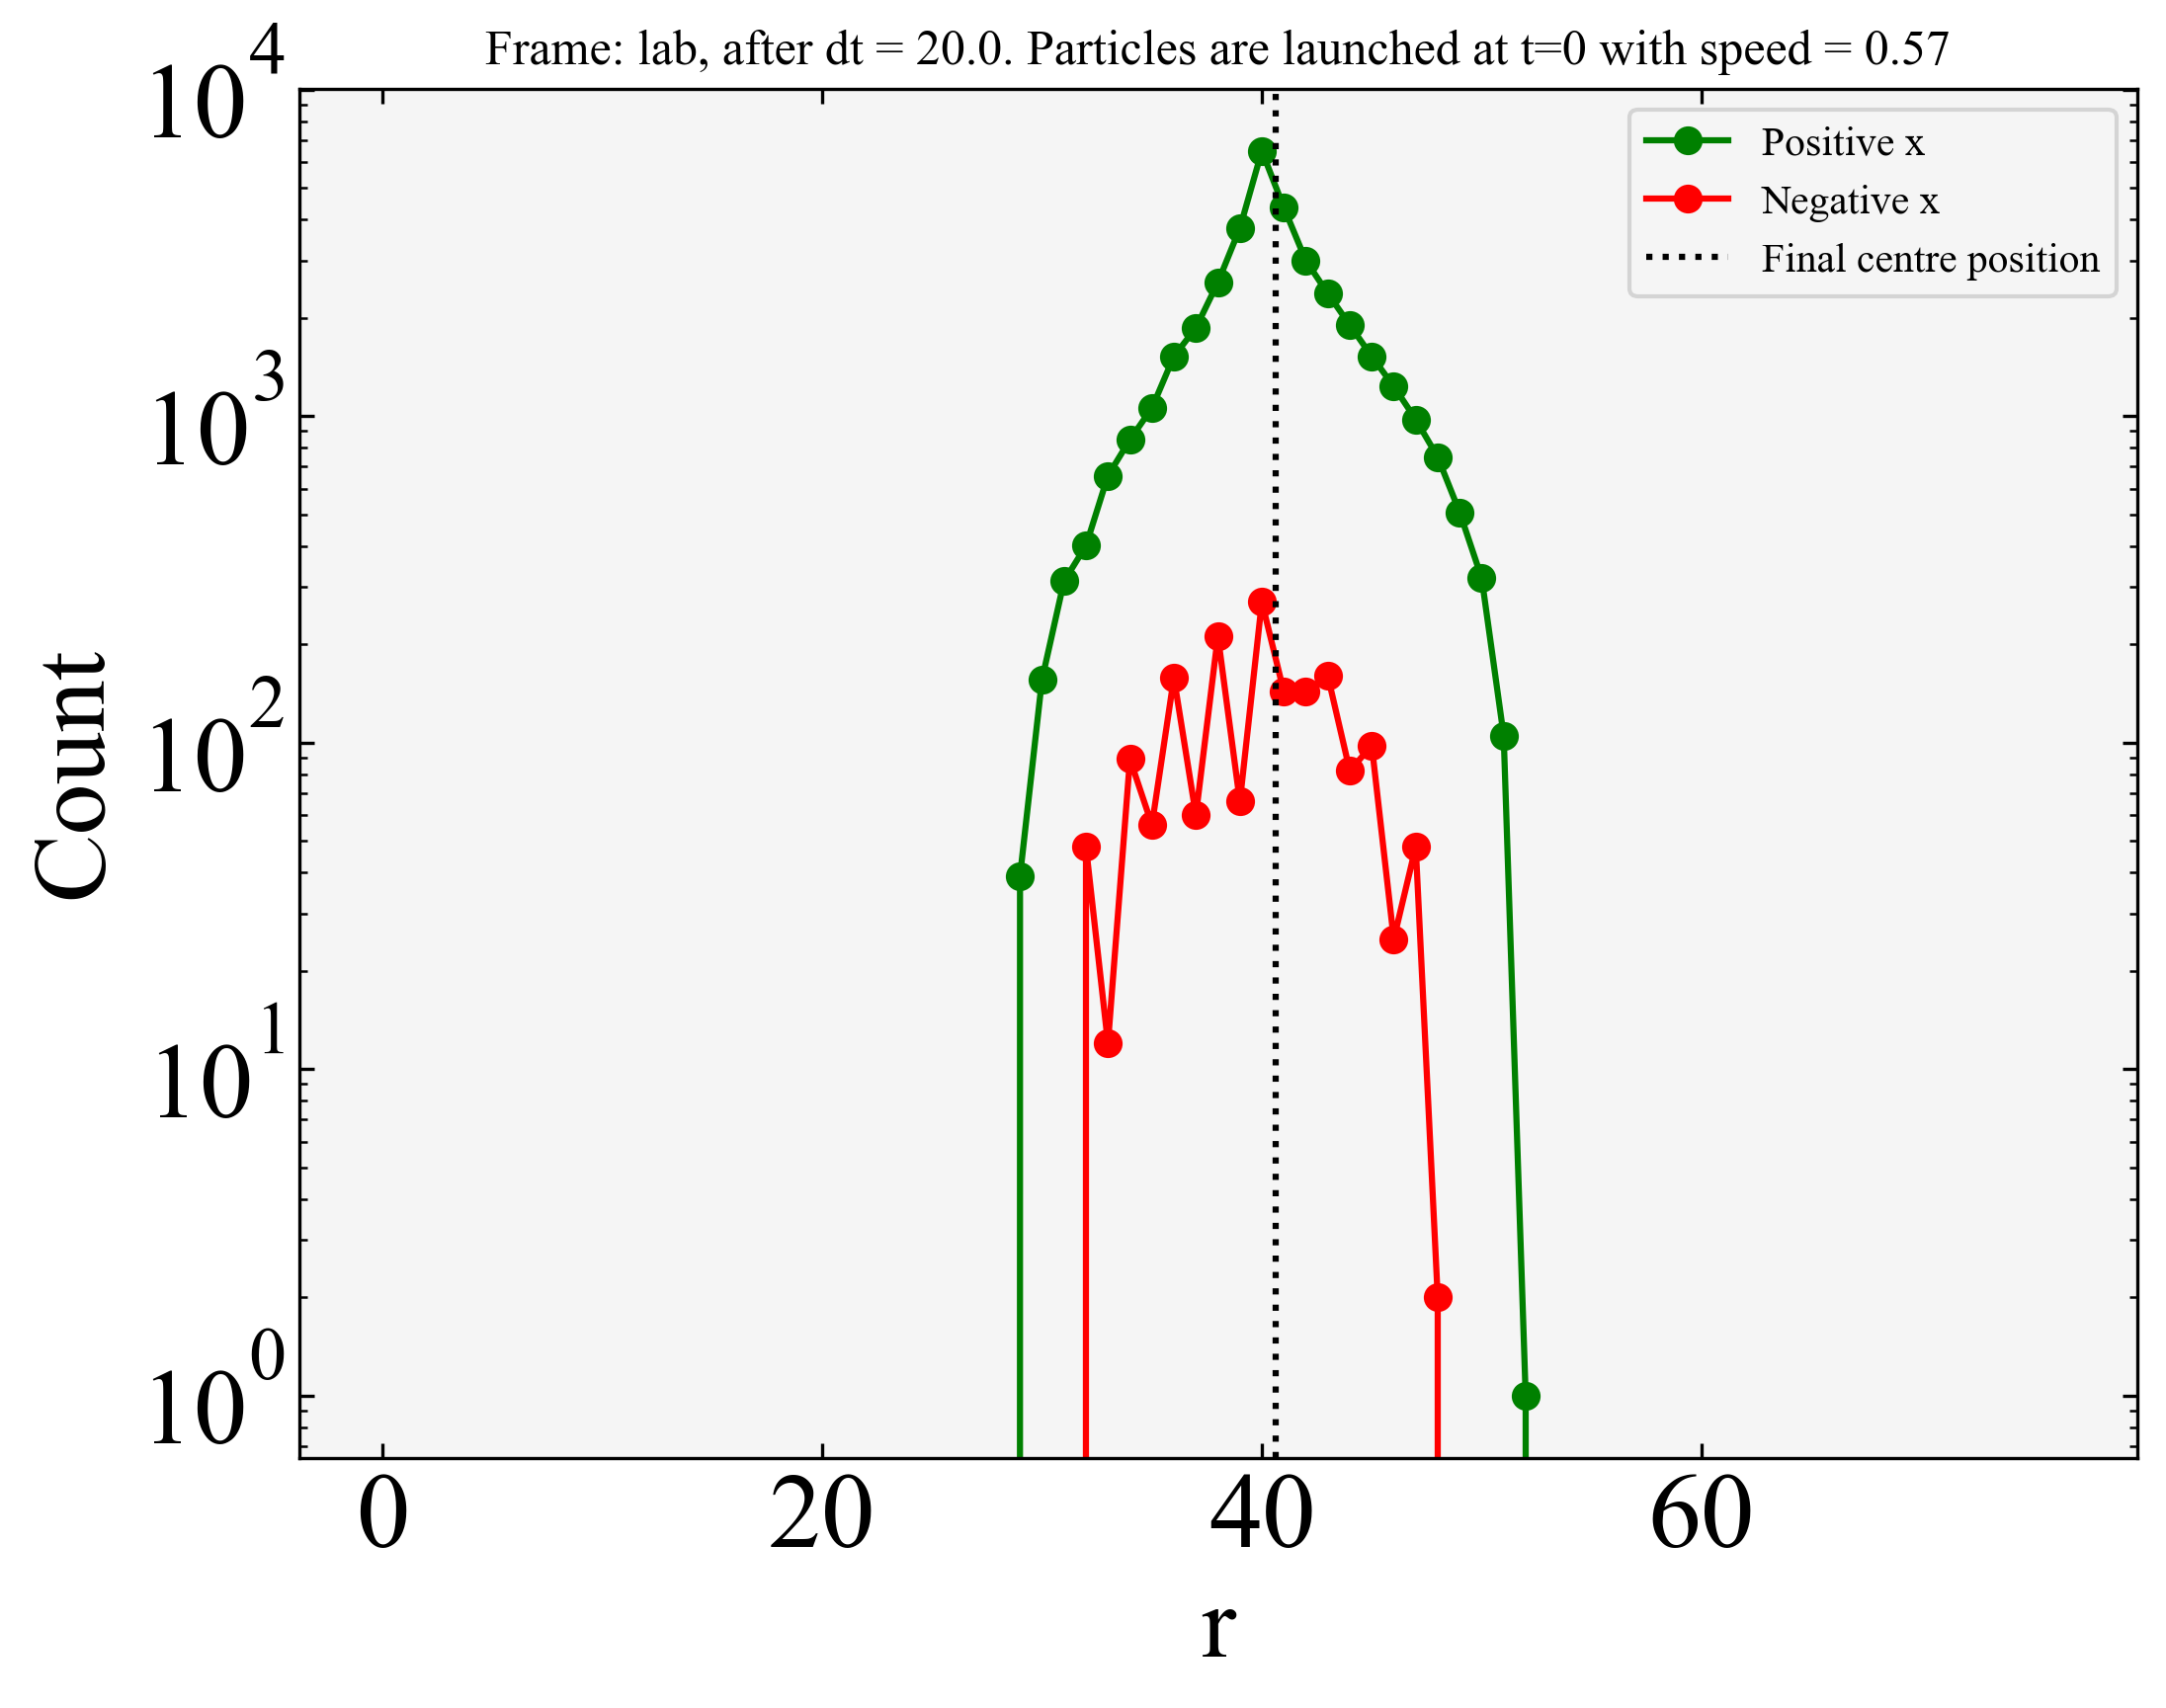

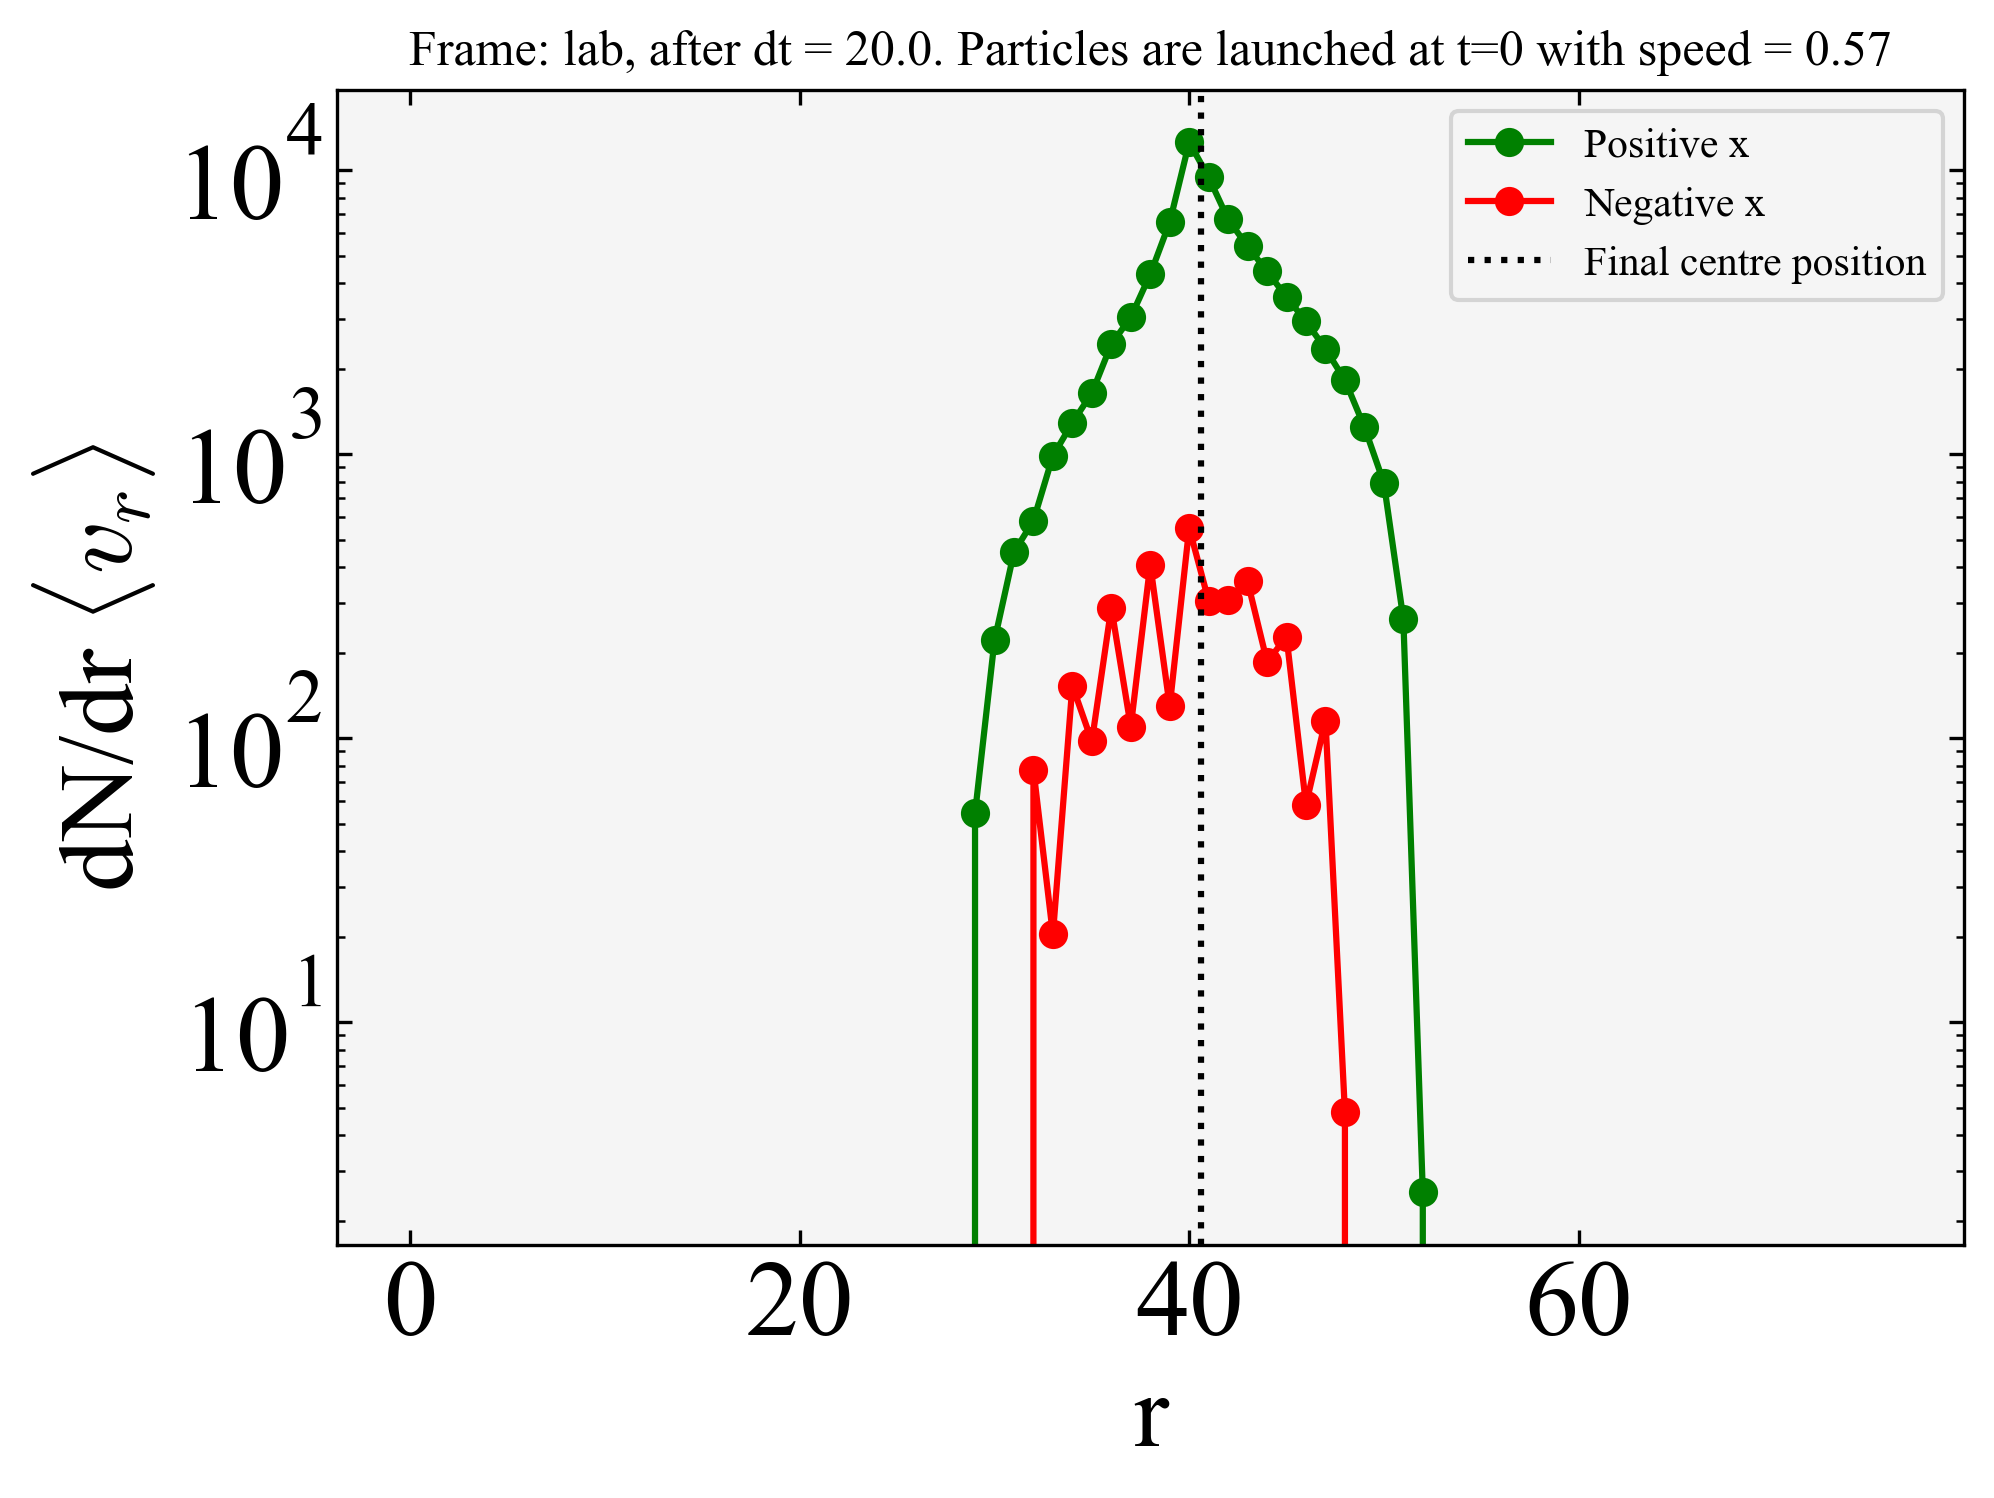

In [22]:
which_frame = 'lab'  # 'lab' or 'centre'
centre_updated = centre  # Initialize the centre for the first iteration
centre_N = [] # will have shape (len(times)-1, 3) 
xyzN = [] # will have shape (len(times)-1, NPIX, 3)
velN = []
orb_en = [] # will have shape (len(times)-1, NPIX)
rmin = 0
rmax = 1.5 * (speed+np.linalg.norm(centre[1])) * times[-1] 
bins_r = 1 #0.5 * single_time * min(speed, np.linalg.norm(centre[1]))
r_bins = np.arange(rmin, rmax, bins_r)

for i, time in enumerate(times[:-1]):
    centre_N.append(centre_updated[0])
    # the firsts are the one who are launched at the initial point and then will expand for all the time. I do some tricks instead of evolving them for all the times
    # To know if they are positive, you have to check their x with respect of the one of the center at each time
    dt = times[-1]-time
    pos_fin, vel_fin, _, _ = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre_updated, dt=dt, which_frame = which_frame, visualize=False) #True if i == 10 else False)
    v_r_N, _, _ = op.to_spherical_components(vel_fin[:,0], vel_fin[:,1], vel_fin[:,2], pos_fin[:,0], pos_fin[:,1], pos_fin[:,2])
    orb_en.append(orbital_energy(np.linalg.norm(pos_fin, axis=1), v_r_N))
    centre_updated = (centre_updated[0] + (times[i+1]-time) * centre_updated[1], centre_updated[1]) 
    xyzN.append(pos_fin)
    velN.append(vel_fin)

xyzN = np.array(xyzN) 
velN = np.array(velN)
plt.figure(figsize=(6, 6))
plt.scatter(np.transpose(centre_N)[0], np.transpose(centre_N)[1], label='Positive x', marker='o', s = 15)
for i in range(len(times)-1):   
    plt.quiver(centre_N[i][0], centre_N[i][1], centre[1][0], centre[1][1], angles='xy', scale_units='xy', scale=1, color='k', width=0.001, headwidth=7, headlength=5)
    if i % 40 == 0:
        plt.quiver(np.repeat(centre_N[i][0], len(np.transpose(observers_xyz))), np.repeat(centre_N[i][1], len(np.transpose(observers_xyz))), np.transpose(velN[i])[0], np.transpose(velN[i])[1], angles='xy', scale_units='xy', scale=1, color='r', width=0.001, headwidth=7, headlength=5)
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-6, 18)
plt.ylim(-50, 2)

xyz_all = np.concatenate(xyzN) # shape (len(times)-1, NPIX, 3) -> (NPIX*(len(times)-1), 3)
xN_all = xyz_all[:, 0]
r_all = np.linalg.norm(xyz_all, axis=1)
vel_all = np.concatenate(velN)
v_r_all, _, _ = op.to_spherical_components(vel_all[:,0], vel_all[:,1], vel_all[:,2], xyz_all[:,0], xyz_all[:,1], xyz_all[:,2])

Rpos= r_all[xN_all > 0] 
Rneg= r_all[xN_all < 0] 
vr_pos = v_r_all[xN_all > 0]
vr_neg = v_r_all[xN_all < 0]
print(f'Positive x: {len(Rpos)}, Negative x: {len(Rneg)} after dt = {times[-1]}')

binRpos, r_bins = np.histogram(Rpos, bins=r_bins)
binRneg, r_bins = np.histogram(Rneg, bins=r_bins)

plt.figure(figsize=(8, 6))
plt.plot(r_bins[:-1], binRpos,'-o', label='Positive x', color='g')
plt.plot(r_bins[:-1], binRneg, '-o', label='Negative x', color='r')
plt.axvline(np.linalg.norm(centre_updated[0]), color='k', linestyle=':', label='Final centre position')
plt.xlabel('r')
plt.ylabel('Count')
plt.title(f'Frame: {which_frame}, after dt = {times[-1]}. Particles are launched at t=0 with speed = {speed:.2f}')
plt.legend()
plt.yscale('log')

Nvr_pos = np.zeros_like(r_bins[:-1])
Nvr_neg = np.zeros_like(r_bins[:-1])
for i, r in enumerate(r_bins[:-1]):
    # check where Rpos is between r and r+bins_r
    cut_count_pos = (Rpos >= r) & (Rpos < r_bins[i+1])
    cut_count_neg = (Rneg >= r) & (Rneg < r_bins[i+1])
    Nvr_pos[i] = len(Rpos[cut_count_pos])* np.mean(vr_pos[cut_count_pos]) if len(Rpos[cut_count_pos]) > 0 else 0
    Nvr_neg[i] = len(Rneg[cut_count_neg])* np.mean(vr_neg[cut_count_neg]) if len(Rneg[cut_count_neg]) > 0 else 0
plt.figure(figsize=(7,5))
plt.plot(r_bins[:-1], Nvr_pos, '-o', label='Positive x', color='g')
plt.plot(r_bins[:-1], Nvr_neg, '-o', label='Negative x', color='r')
plt.axvline(np.linalg.norm(centre_updated[0]), color='k', linestyle=':', label='Final centre position')
plt.xlabel('r')
plt.ylabel(r'dN/dr $\langle v_r \rangle$')
plt.yscale('log')
plt.title(f'Frame: {which_frame}, after dt = {times[-1]}. Particles are launched at t=0 with speed = {speed:.2f}')
plt.legend()



/var/folders/yd/dm2k1v31277b6mkmjgc3x3yh0000gp/T/ipykernel_47116/533131557.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('rainbow', len(times))
/var/folders/yd/dm2k1v31277b6mkmjgc3x3yh0000gp/T/ipykernel_47116/533131557.py:40: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(coordt[0], coordt[1], s = 5, c = cmap(k))


(-150.0, 5.0)

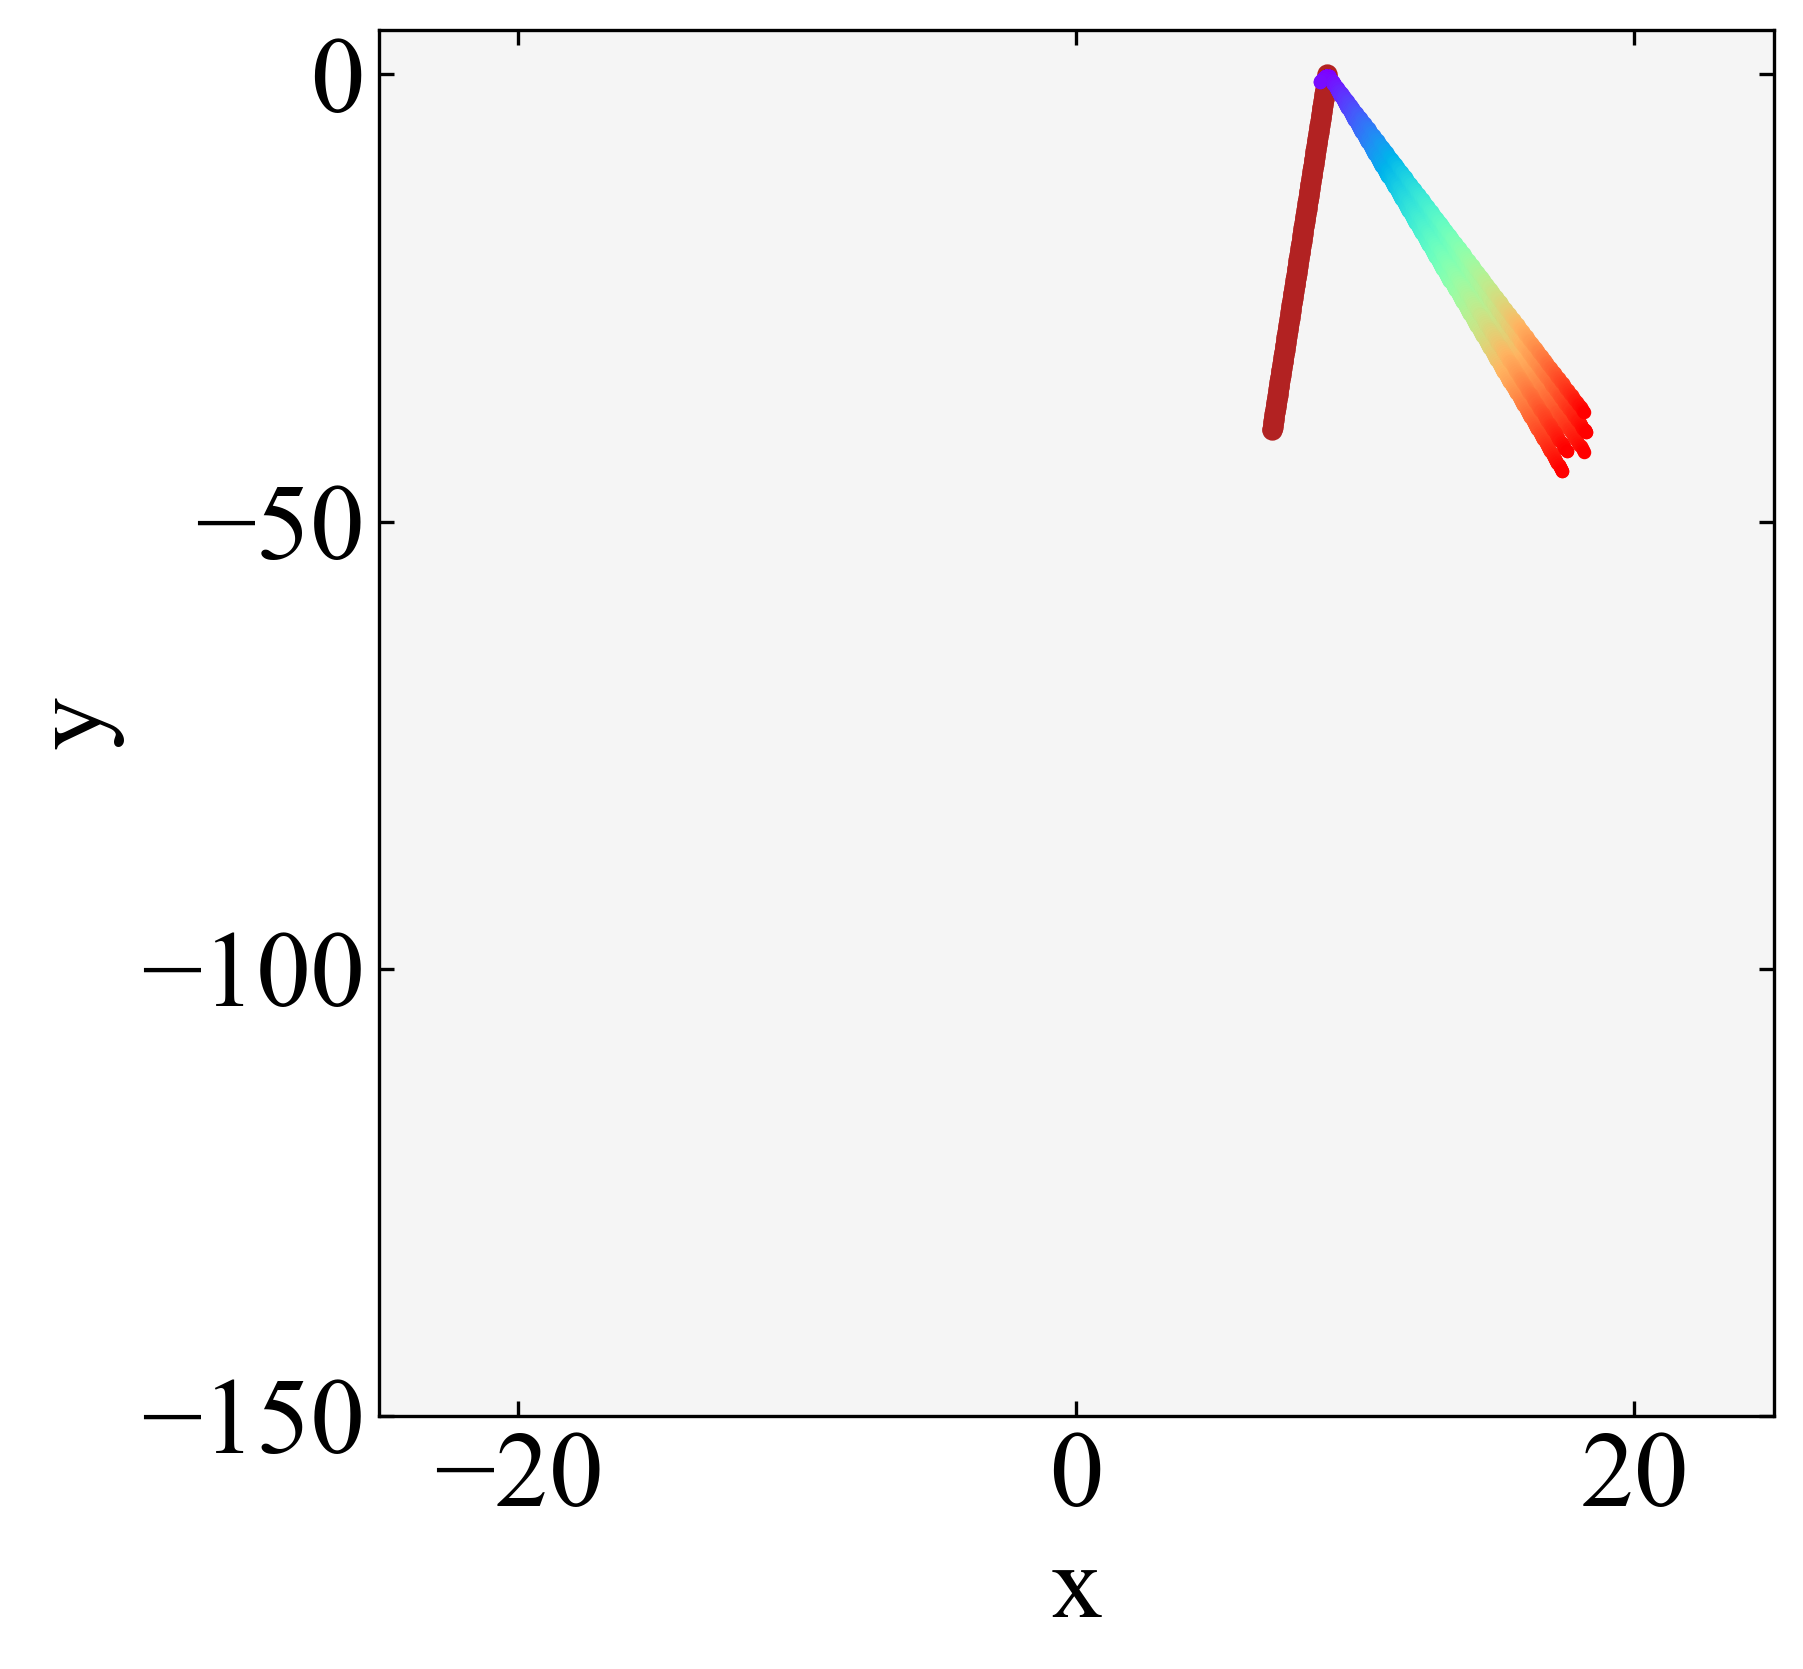

In [16]:
from matplotlib import cm


which_frame = 'lab'  # 'lab' or 'centre'
centre_updated = centre  # Initialize the centre for the first iteration
centre_N = [] # will have shape (len(times)-1, 3) 

xyzV_N = {f'{i}':{} for i in np.arange(len(times))} 
vrN  = {f'{i}':{} for i in np.arange(len(times))}
# orb_en = [] # will have shape (len(times)-1, NPIX)
# rmin = 0
# rmax = 1.5 * (speed+np.linalg.norm(centre[1])) * times[-1] 
# bins_r = 1 #0.5 * single_time * min(speed, np.linalg.norm(centre[1]))
# r_bins = np.arange(rmin, rmax, bins_r)

for i, time in enumerate(times):
    centre_N.append(centre_updated[0])
    pos_fin, vel_fin, pos_c, vel_c = launch_isotropic_particles_boost(N, speed=speed, centre_i=centre_updated, dt=dt, which_frame = which_frame, visualize=False) #True if i == 10 else False)
    v_r_N, _, _ = op.to_spherical_components(vel_fin[:,0], vel_fin[:,1], vel_fin[:,2], pos_fin[:,0], pos_fin[:,1], pos_fin[:,2])
    centre_updated = (pos_c, vel_c) 
    orb_en = orbital_energy(np.linalg.norm(pos_fin, axis=1), v_r_N)
    cut_oe = orb_en > 0 
    pos_fin, vel_fin = pos_fin[cut_oe], vel_fin[cut_oe]
    for j, time_aft in enumerate(times[i:]):
        pos_t = pos_fin + vel_fin * (time_aft-time)
        v_r_t, _, _ = op.to_spherical_components(vel_fin[:,0], vel_fin[:,1], vel_fin[:,2], pos_t[:,0], pos_t[:,1], pos_t[:,2])
        orb_en = orbital_energy(np.linalg.norm(pos_t, axis=1), v_r_t)
        cut_oe = orb_en > 0 
        pos_t, pos_fin, vel_fin = pos_t[cut_oe], pos_fin[cut_oe], vel_fin[cut_oe]
        v_r_t, _, _ = op.to_spherical_components(vel_fin[:,0], vel_fin[:,1], vel_fin[:,2], pos_t[:,0], pos_t[:,1], pos_t[:,2])
        xyzV_N[f'{i+j}'][f'{i}'] = {'pos': pos_t,
                                    'VrN': v_r_t}
                                    
plt.figure(figsize=(6, 6))
plt.scatter(np.transpose(centre_N)[0], np.transpose(centre_N)[1], marker = 'o', s = 15)
cmap = cm.get_cmap('rainbow', len(times))
for k in np.arange(len(times)):
    coordt = np.transpose(xyzV_N[f'{k}']['0']['pos'])
    # set colors to the kth of rainbow map
    plt.scatter(coordt[0], coordt[1], s = 5, c = cmap(k))
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-25, 25)
plt.ylim(-150, 5)

# xyz_all = np.concatenate(xyzN) # shape (len(times)-1, NPIX, 3) -> (NPIX*(len(times)-1), 3)
# xN_all = xyz_all[:, 0]
# r_all = np.linalg.norm(xyz_all, axis=1)
# vel_all = np.concatenate(velN)
# v_r_all, _, _ = op.to_spherical_components(vel_all[:,0], vel_all[:,1], vel_all[:,2], xyz_all[:,0], xyz_all[:,1], xyz_all[:,2])

# Rpos= r_all[xN_all > 0] 
# Rneg= r_all[xN_all < 0] 
# vr_pos = v_r_all[xN_all > 0]
# vr_neg = v_r_all[xN_all < 0]


# binRpos, r_bins = np.histogram(Rpos, bins=r_bins)
# binRneg, r_bins = np.histogram(Rneg, bins=r_bins)

# plt.figure(figsize=(8, 6))
# plt.plot(r_bins[:-1], binRpos,'-o', label='Positive x', color='g')
# plt.plot(r_bins[:-1], binRneg, '-o', label='Negative x', color='r')
# plt.axvline(np.linalg.norm(centre_updated[0]), color='k', linestyle=':', label='Final centre position')
# plt.xlabel('r')
# plt.ylabel('Count')
# plt.title(f'Frame: {which_frame}, after dt = {single_time}. Particles are launched at t=0 with speed = {speed:.2f}')
# plt.legend()
# plt.yscale('log')

# Nvr_pos = np.zeros_like(r_bins[:-1])
# Nvr_neg = np.zeros_like(r_bins[:-1])
# for i, r in enumerate(r_bins[:-1]):
#     # check where Rpos is between r and r+bins_r
#     cut_count_pos = (Rpos >= r) & (Rpos < r_bins[i+1])
#     cut_count_neg = (Rneg >= r) & (Rneg < r_bins[i+1])
#     Nvr_pos[i] = len(Rpos[cut_count_pos])* np.mean(vr_pos[cut_count_pos]) if len(Rpos[cut_count_pos]) > 0 else 0
#     Nvr_neg[i] = len(Rneg[cut_count_neg])* np.mean(vr_neg[cut_count_neg]) if len(Rneg[cut_count_neg]) > 0 else 0
# plt.figure(figsize=(7,5))
# plt.plot(r_bins[:-1], Nvr_pos, '-o', label='Positive x', color='g')
# plt.plot(r_bins[:-1], Nvr_neg, '-o', label='Negative x', color='r')
# plt.axvline(np.linalg.norm(centre_updated[0]), color='k', linestyle=':', label='Final centre position')
# plt.xlabel('r')
# plt.ylabel(r'dN/dr $\langle v_r \rangle$')
# plt.yscale('log')
# plt.title(f'Frame: {which_frame}, after dt = {single_time}. Particles are launched at t=0 with speed = {speed:.2f}')
# plt.legend()

